In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from config.constants import Paths

plt.style.use("src/mplstyles/lncs.mplstyle")
df_pv = pd.read_csv(Paths.LITERATURE_STUDY / "literature_review_pv.csv")
df_wind = pd.read_csv(Paths.LITERATURE_STUDY / "literature_review_wt.csv")

df_wind.loc[:, "Used Evaluation Metrics"] = df_wind["Used Evaluation Metrics"].fillna("None")

/app/logs


# 1 Literature Review on WTPC Modelling

## 1.1 Frequency of Models, Features and Metrics

In [2]:
# Definition of categories
rename_dict = dict()
rename_dict["model"] = {
    "XGBoost": "Tree-based",
    "LightGBM": "Tree-based",
    "RF": "Tree-based",
    "M5-Prime": "Tree-based",
    "CatBoost": "Tree-based",
    "AdaBoost": "Tree-based",
    "SGBRT": "Tree-based",
    "QRF": "Tree-based",
    "Gradient Boosting Regression": "Tree-based",
    "Decision Tree": "Tree-based",
    "BART": "Tree-based",

    "MLP": "Neural Network",
    "ANN": "Neural Network",
    "Feed forward NN": "Neural Network",
    "CNN": "Neural Network",
    "RNN": "Neural Network",
    "LSTM": "Neural Network",
    "GRU": "Neural Network",
    "DBN": "Neural Network",
    "RBFNN": "Neural Network",
    "Extreme Learning Machine (ELM)": "Neural Network",
    "NN with Quantile Loss": "Neural Network",
    "CVAE": "Neural Network",
    "Wavelet": "Neural Network",
    "adaptive neuro-fuzzy interference system (ANFIN)": "Neural Network",

    "Linear model": "Linear / GLM",
    "Piece-wise Linear Regression": "Linear / GLM",
    "Linear hinges model": "Linear / GLM",
    # "Logistic Regression": "Linear / GLM",
    "GLM": "Linear / GLM",
    "Ordinary Least Squares": "Linear / GLM",
    "LASSO": "Linear / GLM",

    "SVR": "Kernel / Nonparametric",
    "AMK": "Kernel / Nonparametric",
    "Conditional Kernel Density Estimation": "Kernel / Nonparametric",
    # "Nadaraya-Watson Kernel Estimator": "Kernel / Nonparametric",
    "Radial Basis Function (RBF)": "Kernel / Nonparametric",
    "Fuzzy Clustering": "Kernel / Nonparametric",
    "CCFL": "Kernel / Nonparametric",
    ###

    "Gaussian Process": "Bayesian",
    "Bayesian hierarchical inference": "Bayesian",
    "MLE": "Bayesian",
    "MCS": "Bayesian",
    "Relevance Vector Machine": "Bayesian",

    "Logarithmic Regression": "Statistical",
    "Cubic model": "Statistical",
    "Quadratic model": "Statistical",
    "Exponential model": "Statistical",
    "EWMA": "Statistical",
    "GWMA": "Statistical",
    "Autoregressive Model (AR)": "Statistical",
    "Weibull CDF model": "Statistical",
    "Rayleigh Wind Distribution Model": "Statistical",
    "Sum of Sines": "Statistical",
    "Fourier Series Interpolation": "Statistical",
    "Mode approach": "Statistical",
    "Logistic Function": "Statistical",
    "Modified hyperbolic tangent function": "Statistical",
    "Gaussian Model": "Statistical",
    "Gaussian wake model": "Statistical",
    "Ratio Model": "Statistical",
    "Polynomial regression": "Statistical",
    "Polynomial model": "Statistical",
    "Piece-wise Polynomial Regression": "Statistical",
    "Piece-wise Exponential Regression": "Statistical",
    "SHMSRM": "Statistical",
    "SSANOVA": "Statistical",
    "piecewise cubic Hermite interpolating polynomial": "Statistical",
    "General model": "Statistical",
    "Power Surface": "Statistical",
    "BVK": "Statistical",
    "RSM": "Statistical",

    "Jensen's Wake Model": "Physics-informed",
    "Shihara-Qian wake model": "Physics-informed",
    "IEC Standard": "Physics-informed",
    "Power-coefficient based model": "Physics-informed",
    "PARK model": "Physics-informed",
    "LES with Smagorinsky-Lill model": "Physics-informed",
    "SDE": "Physics-informed",

}

rename_dict["feature"] = {
    "Wind Speed": "Wind Speed",

    # --- Wind Direction & Orientation ---
    "Wind Direction": "Inflow Direction",
    "inflow angle": "Inflow Direction",
    "Yaw Misalignment": "Yaw Control",
    "yaw angle": "Yaw Control",
    "Nacelle Orientation": "Yaw Control",
    "Tilt Yaw Control": "Yaw Control",

    # --- Blade Pitch & Hydraulics ---
    "Blade Pitch Angle": "Blade Pitch Control",
    "Blade Pitch Travelled Distance": "Blade Pitch Control",
    "Blade Piston Travelled Distance": "Blade Pitch Control",
    "Blade Pitch Manifold Oil Pressure": "Blade Pitch Hydraulics",
    "Blade Pitch Cylinder Pressure": "Blade Pitch Hydraulics",

    # --- Blade Load & Structural Loads ---
    "Blade Load": "Mechanical Loads",
    "Blade Loads Bearing Tilt Moment": "Mechanical Loads",
    "Blade Loads Bearing Yaw Moment": "Mechanical Loads",
    "Tilt Moment": "Mechanical Loads",
    "Yaw Moment": "Mechanical Loads",

    # --- Generator & Electrical System ---
    "Generator speed": "Generator Speed",
    "Voltage": "Electrical Output",
    "Current": "Electrical Output",

    # --- Tower Dynamics ---
    "Tower Vibrations": "Tower Vibrations",
    "Tower Acceleration": "Tower Acceleration",

    # --- Aerodynamics / Efficiency ---
    "Axial Induction Factor": "Aerodynamic Performance",
    "power density": "Aerodynamic Performance",
    "aerodynamic efficiency": "Aerodynamic Performance",

    # --- Power Curve Modeling ---
    "Theoretical_Power_Curve": "Theoretical Power Model",
    "Normalized Wind Power": "Normalized Power",

    # --- Turbine Operating Thresholds ---
    "cut-in speed": "Operating Thresholds",
    "cut-out speed": "Operating Thresholds",

    # --- Environmental Context / Terrain / Wake ---
    "Power of nearby turbines": "Site Conditions",
    "wake effect": "Site Conditions",
    "Terrain Gradient": "Site Conditions",

    # --- Time Feature ---
    "Datetime": "Temporal Feature"
}

In [3]:
included = df_wind["No Survey / Literature Review"] & df_wind[
    "Contains Experiments and Results for WTPC"] & df_wind["Full Text Available"]
print(f"Discarded {(~included).sum()} rows due to exclusion criteria.")
df_wind = df_wind.loc[included]

Discarded 38 rows due to exclusion criteria.


In [4]:
print(f"Only {np.count_nonzero(df_wind['Source Code Availability'] == 'Yes') / len(df_wind) * 100:.2f}% of the reviewed papers provide their source code.")
print(f"Only {np.count_nonzero(df_wind['Dataset Availability'].isin(['Yes', 'On Request'])) / len(df_wind) * 100:.2f}% of the reviewed papers provide the dataset (at least on request).")

Only 4.44% of the reviewed papers provide their source code.
Only 17.78% of the reviewed papers provide the dataset (at least on request).


In [5]:
# Wind speed was assumed to be a standard feature. It was only documented if it was exceptionally not used, or used as the sole feature. Here, for further analysis, "Wind Speed Only" should simply be replaced with "Wind Speed", and for all other papers for which "No Wind Speed" was not recorded, "Wind Speed" should be added.
wind_speed_only_rows = df_wind["Used Features"].str.contains("Wind Speed Only")
no_wind_speed_rows = df_wind["Used Features"].str.contains("No Wind Speed")
wind_speed_only_dois = df_wind.loc[wind_speed_only_rows, "doi"]
df_wind.loc[:, "Used Features"] = df_wind["Used Features"].str.replace("Wind Speed Only", "Wind Speed")
df_wind.loc[(~no_wind_speed_rows) & (~wind_speed_only_rows), "Used Features"] += ", Wind Speed"

In [6]:
df_wind.loc[:, "Used Features"] = df_wind.loc[:, "Used Features"].str.split(",").apply(lambda x: [s.strip() for s in x])
df_wind.loc[:, "Used Models"] = df_wind.loc[:, "Used Models"].str.split(",").apply(lambda x: [s.strip() for s in x])
df_wind.loc[:, "Used Evaluation Metrics"] = df_wind.loc[:, "Used Evaluation Metrics"].str.split(",").apply(lambda x: [s.strip() for s in x])

df_wind.loc[:, "feature_count"] = df_wind.loc[:, "Used Features"].apply(len)
df_wind.loc[:, "model_count"] = df_wind.loc[:, "Used Models"].apply(len)
df_wind.loc[:, "metric_count"] = df_wind.loc[:, "Used Evaluation Metrics"].apply(len)

# df_wind.loc[:, "Used Features"] = df_wind.loc[:, "Used Features"].astype(str)
# df_wind.loc[:, "Used Features"] = df_wind.loc[:, "Used Features"].apply(lambda x: [s.strip() for s in x.split(",")])

In [7]:
# Get bar diagram for both used models and features
count_series = dict()
for old_colname, new_colname in zip(["Used Features", "Used Models"], ["feature", "model"]):
    # using doi as unique paper identifier
    # make sure there are no NaNs in the features column
    assert not df_wind[old_colname].isna().any()
    curr_df = df_wind.loc[:, ["doi", old_colname]].rename(columns={old_colname: new_colname})
    # splitting comma separated lists into actual lists of strings
    # print(curr_df)
    curr_df = curr_df.explode(new_colname, ignore_index=True)
    curr_df = curr_df.drop_duplicates()
    if new_colname in rename_dict:
        curr_df[new_colname] = curr_df[new_colname].map(lambda x: rename_dict[new_colname].get(x, x))
    # print(curr_df[new_colname])
    curr_df = curr_df.drop_duplicates()
    value_counts_df = curr_df[new_colname] \
        .value_counts() \
        .reset_index(name="count") \
        .rename(columns={"index": new_colname})
    frequent_df = value_counts_df.query("count > 1").copy()
    rare_total = value_counts_df.query("count == 1")["count"].sum()
    if rare_total > 0:
        others_row = pd.DataFrame([{new_colname: "Others", "count": rare_total}])
        frequent_df = pd.concat([frequent_df, others_row], ignore_index=True)
    count_series[new_colname] = frequent_df
    # print(curr_df)

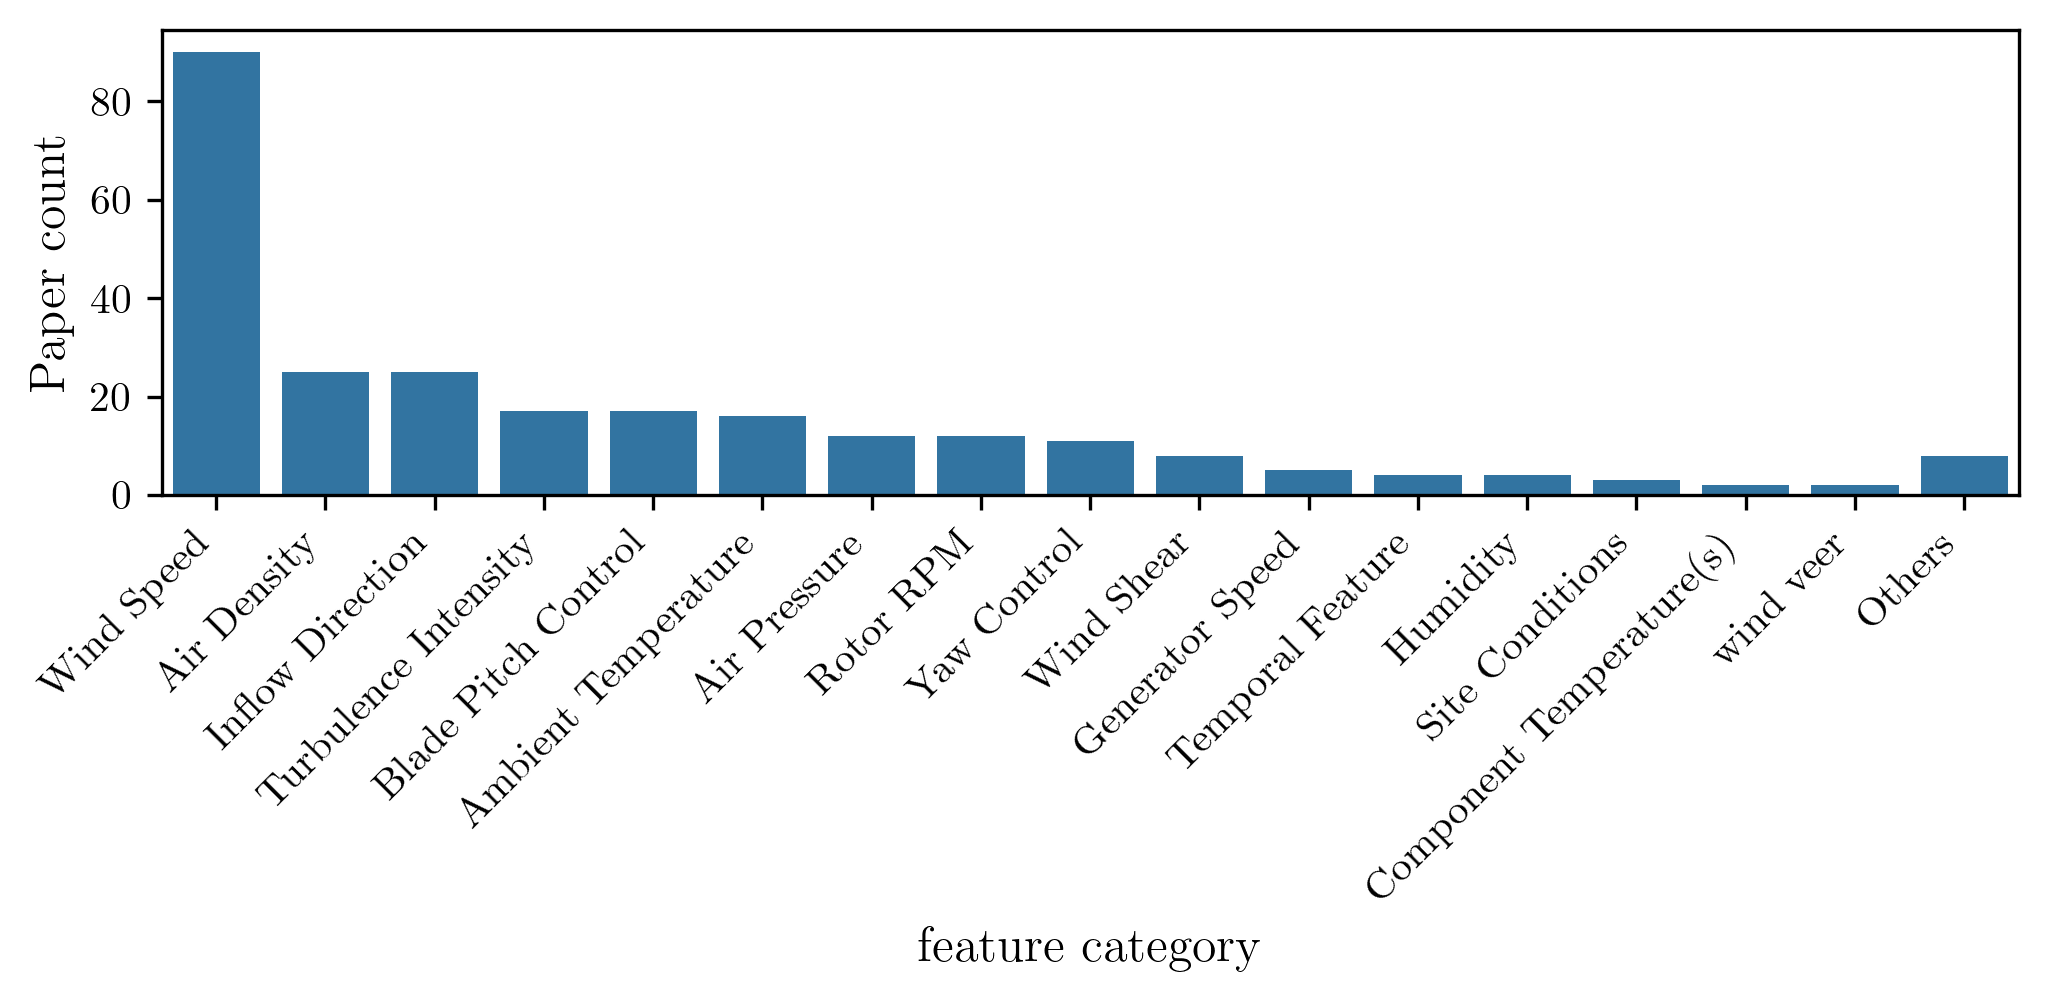

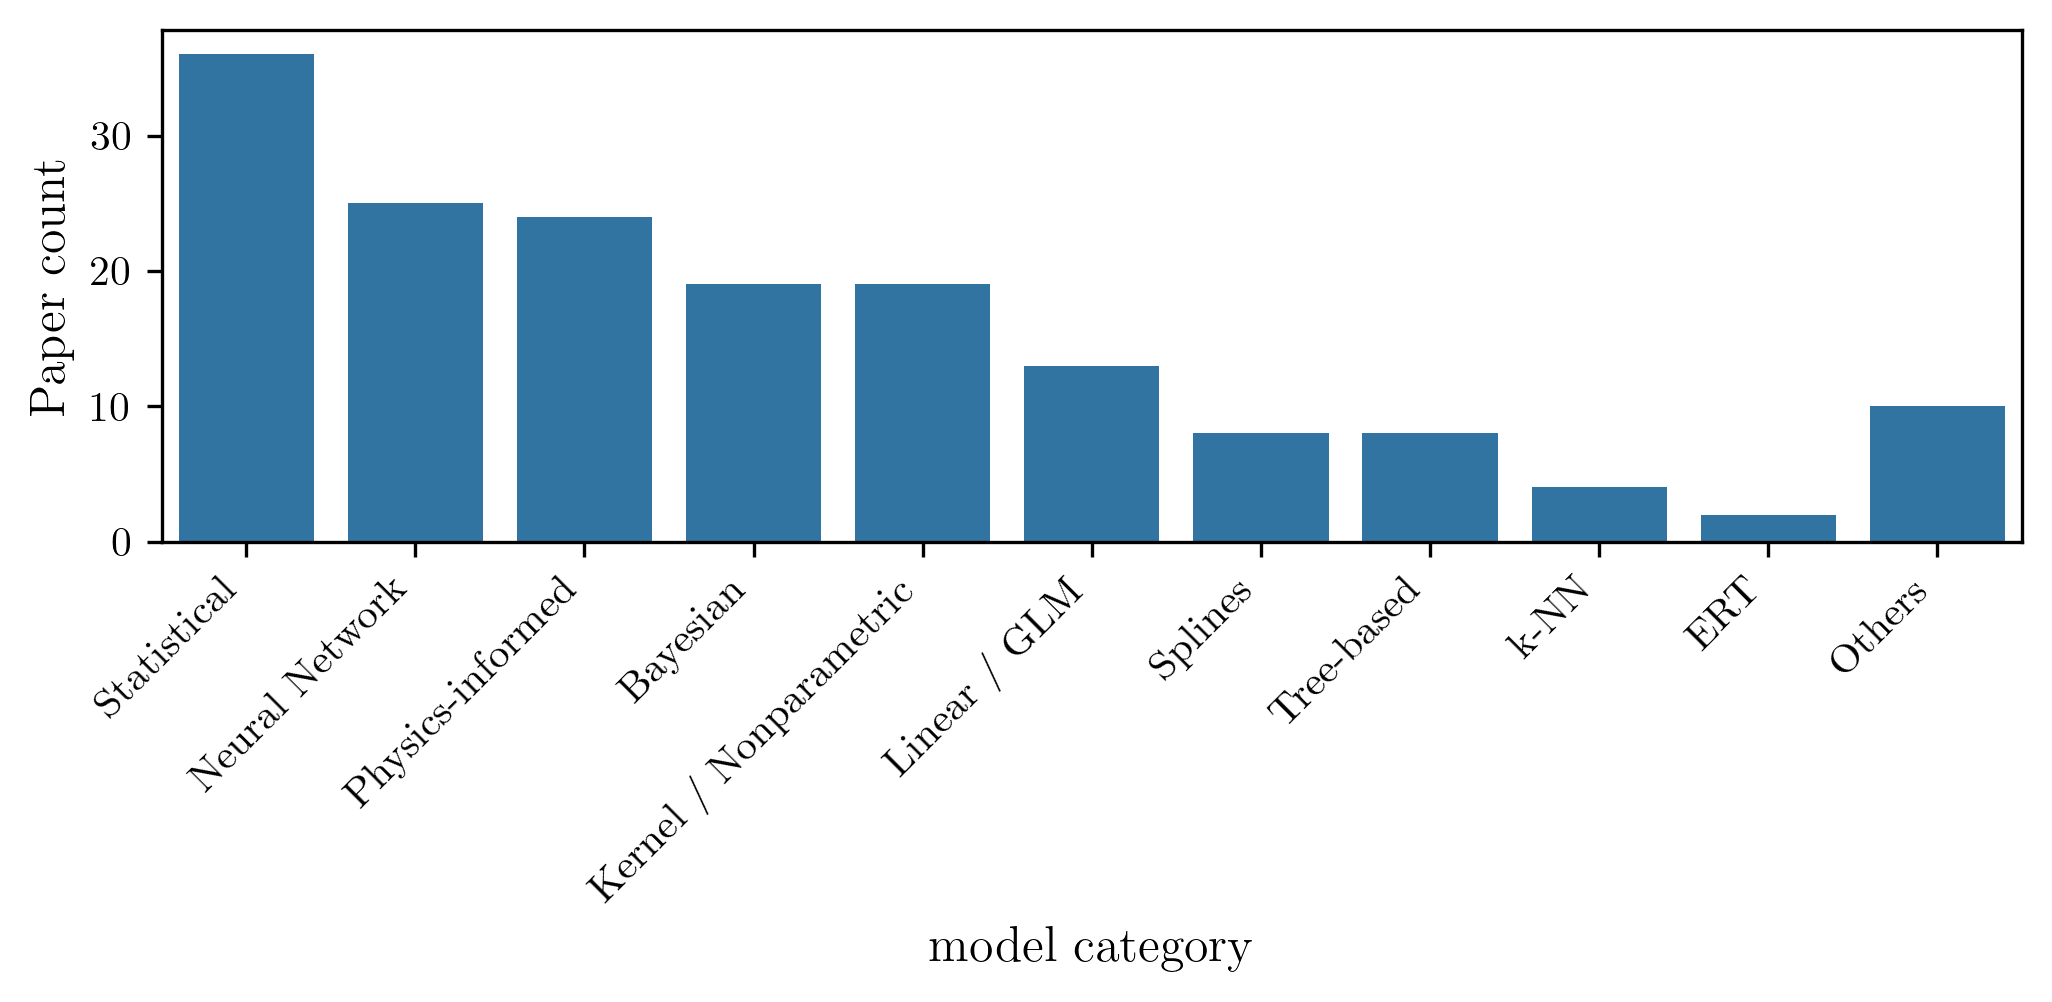

In [8]:
for s, k in zip(["feature", "model"], count_series.keys()):
    fig, ax = plt.subplots()
    sns.barplot(
        data=count_series[k],
        x=k,
        y="count",
        ax=ax
    )
    ax.set_ylabel("Paper count")
    ax.set_xlabel(f"{s} category")
    fig.autofmt_xdate(rotation=45)
    fig.tight_layout()
    plt.show()

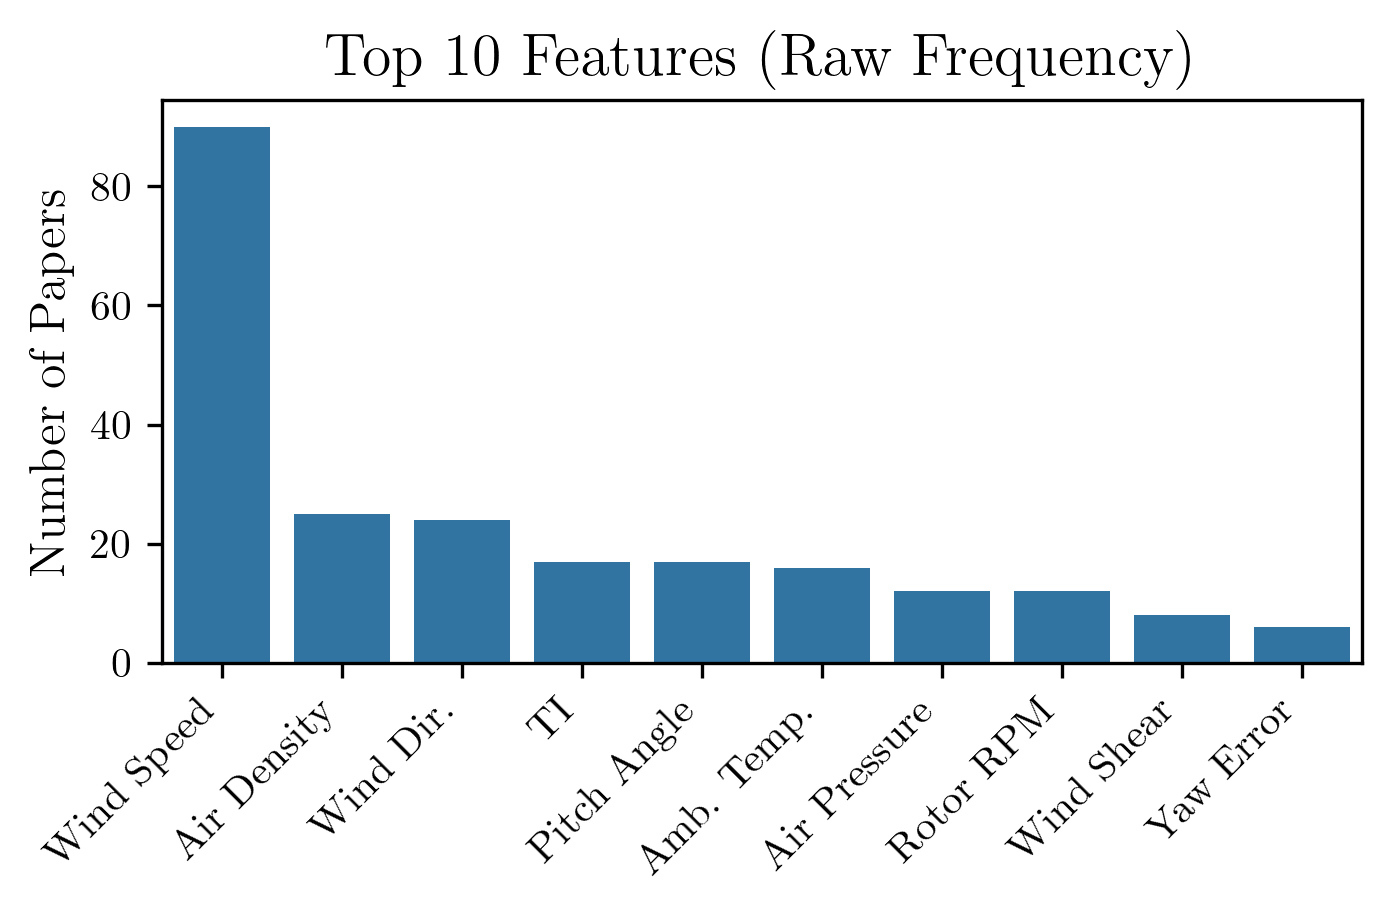

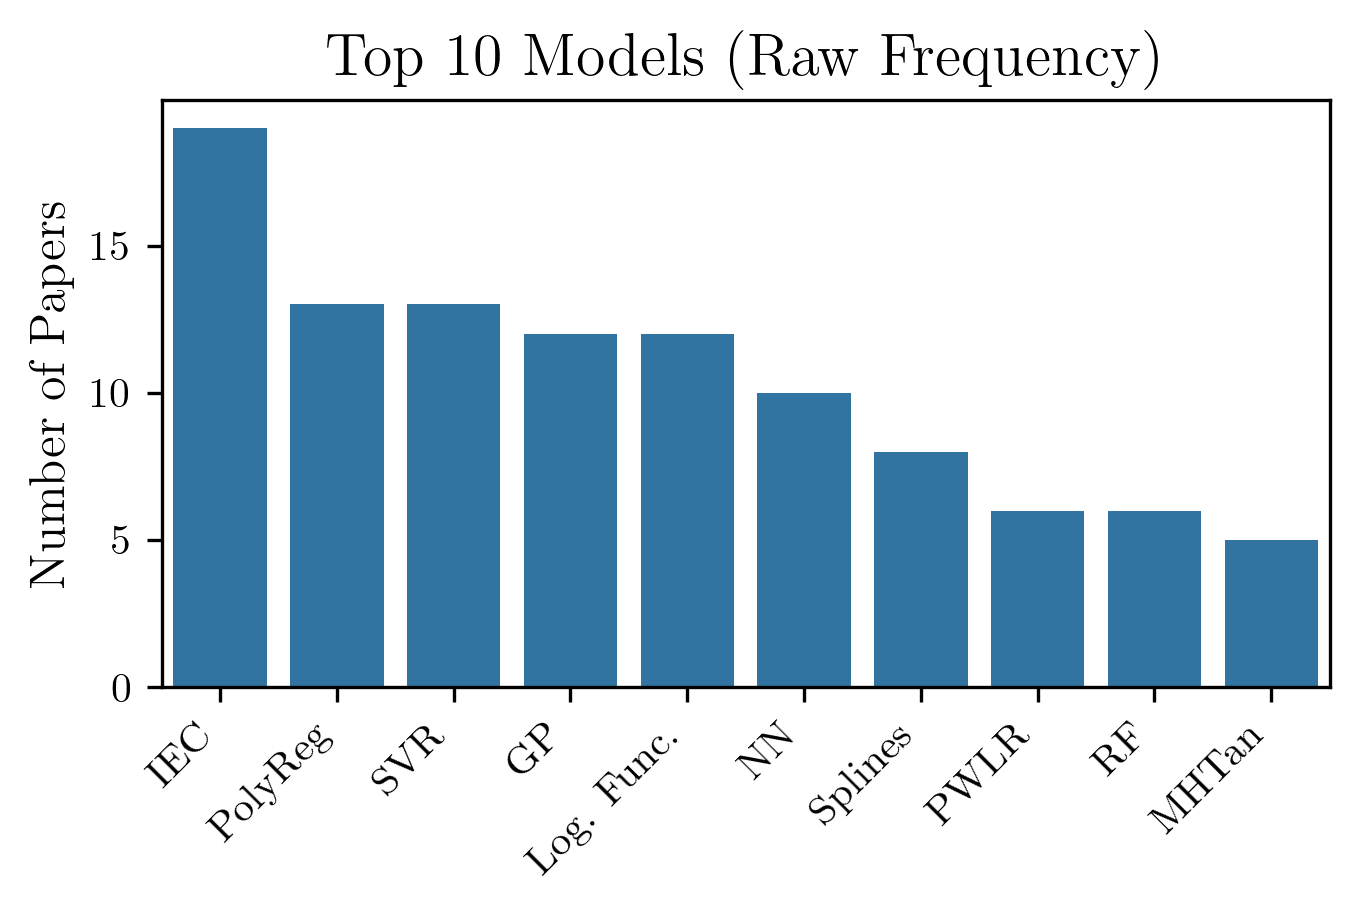

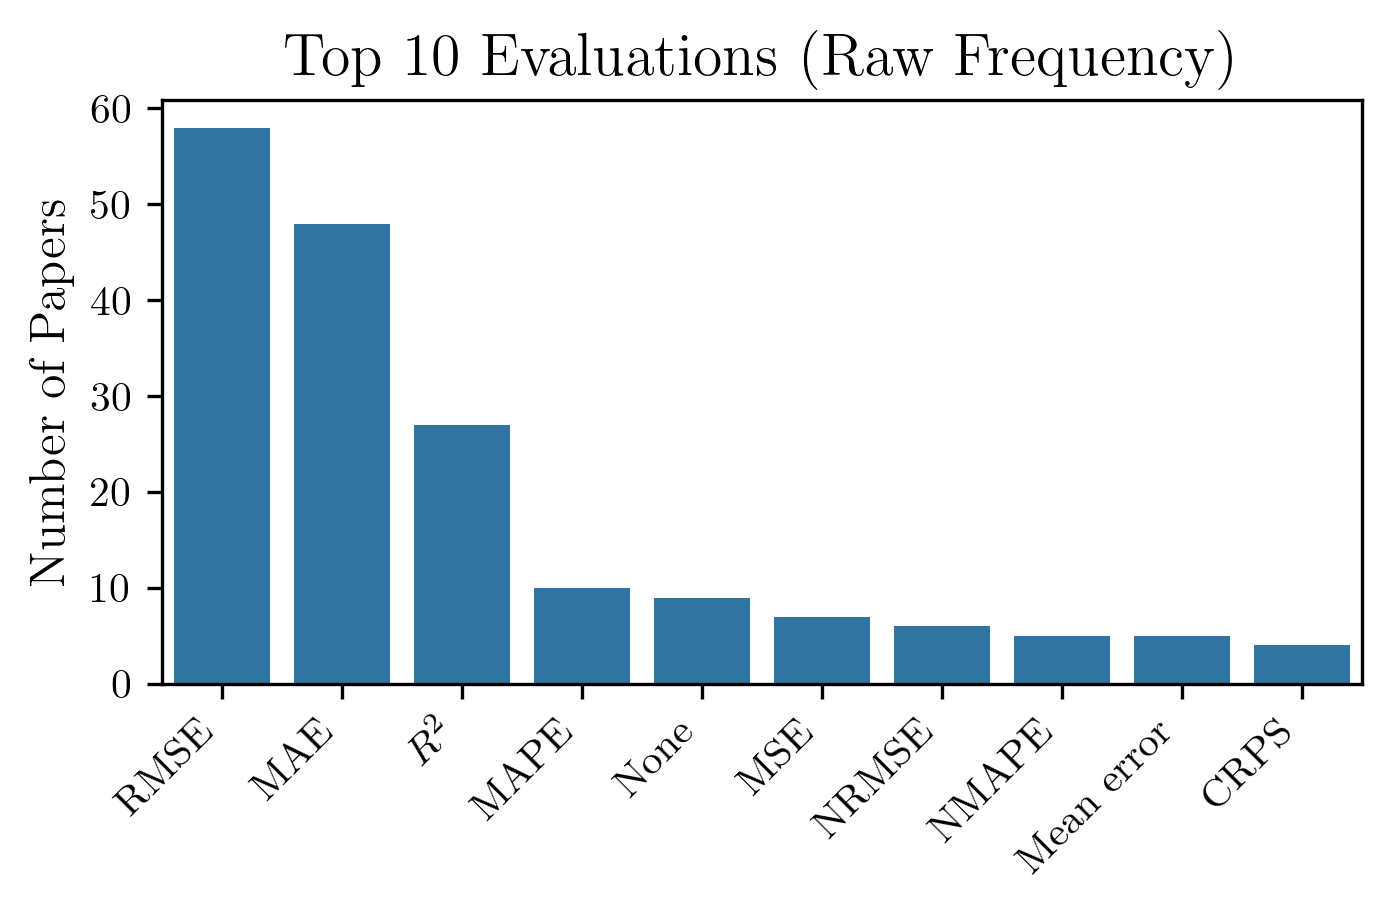

In [9]:
# Generation of a better-readable plot with shortened labels
short_names = {
    "feature": {
        "Wind Direction": "Wind Dir.",
        "Turbulence Intensity": "TI",
        "Ambient Temperature": "Amb. Temp.",
        "Yaw Misalignment": "Yaw Error",
        "Blade Pitch Angle": "Pitch Angle",
    },
    "model": {
        "IEC Standard": "IEC",
        "Piece-wise Linear Regression": "PWLR",
        "Piece-wise Polynomial Regression": "PolyReg",
        "Polynomial regression": "PolyReg",
        "Modified hyperbolic tangent function": "MHTan",
        "Gaussian Process": "GP",
        "Logistic Function": "Log. Func.",
        "Feed forward NN": "NN",
    },
    "evaluation": {"R^2": "$R^2$"},
}

with plt.style.context("src/mplstyles/lncs_small.mplstyle"):
    # Global bar plots: top 10 individual items (raw names, not grouped into supercategories)
    usage_counts = {}
    counts = {}
    for xlabel, colname_raw in zip(
            ["Feature", "Model", "Evaluation metric"],
            ["Used Features", "Used Models", "Used Evaluation Metrics"]):
        coltype = "feature" if "Feature" in colname_raw else "model" if "Models" in colname_raw else "evaluation"

        # Prepare data
        df_expanded = df_wind.loc[:, ["doi", colname_raw]].rename(columns={colname_raw: coltype})
        df_expanded = df_expanded.explode(coltype)

        df_expanded[coltype] = df_expanded[coltype].replace(
            short_names[coltype]
        )

        df_expanded = df_expanded.drop_duplicates()
        usage_counts[coltype] = df_expanded.groupby("doi").count()  #.value_counts()

        # Count and take top 10
        counts[coltype] = df_expanded[coltype].value_counts().head(10).reset_index()
        counts[coltype].columns = [coltype, "count"]

        # Plot
        fig, ax = plt.subplots()
        sns.barplot(data=counts[coltype], x=coltype, y="count", ax=ax)
        fig_title = f"Top 10 {coltype.capitalize()}s (Raw Frequency)"
        ax.set_title(fig_title)
        ax.set_xlabel("")  # xlabel)
        ax.set_ylabel("Number of Papers")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

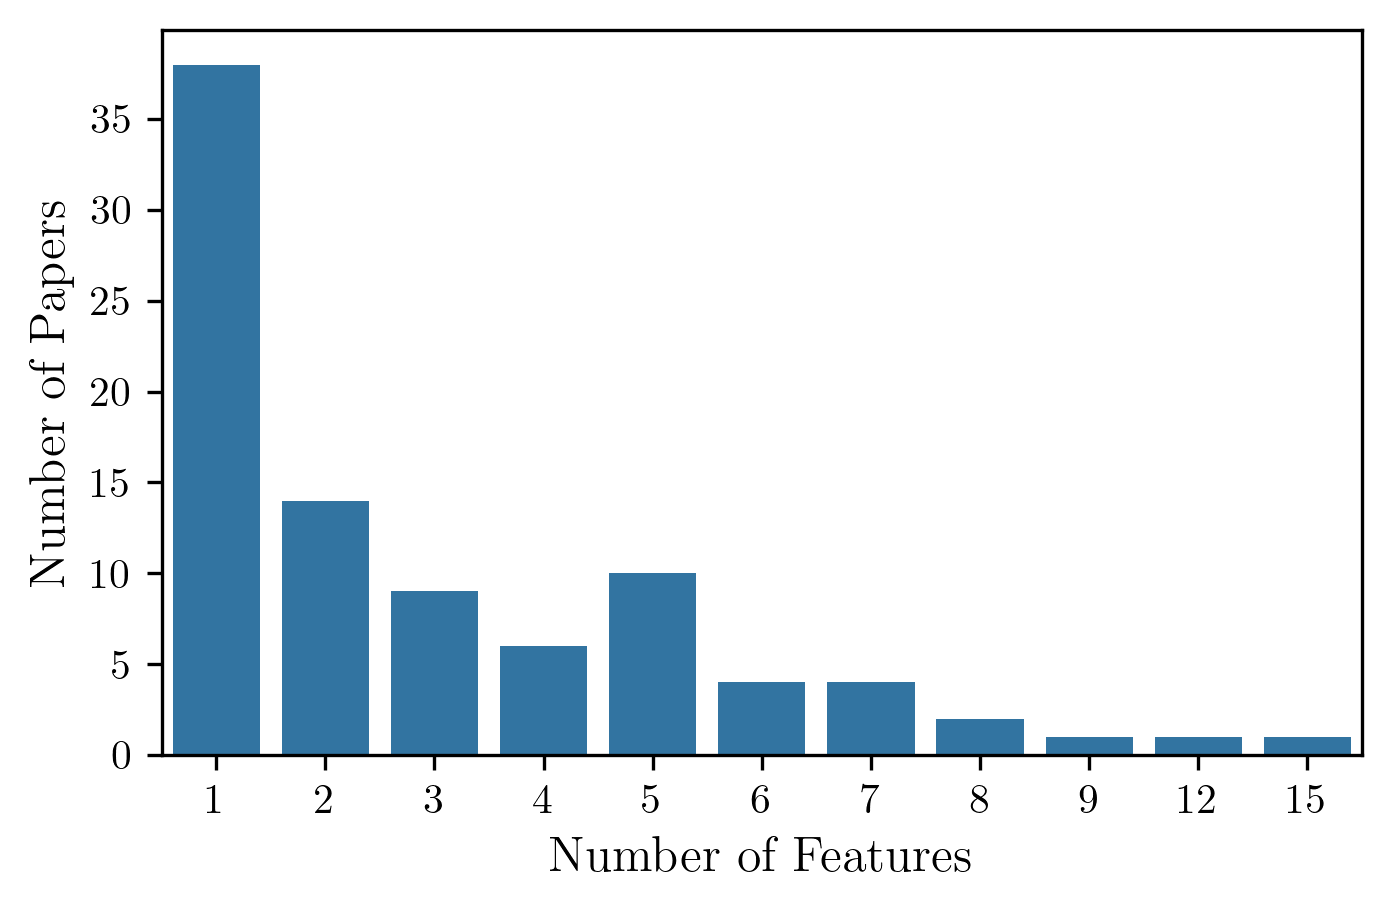

In [10]:
with plt.style.context("src/mplstyles/lncs_small.mplstyle"):
    fig, ax = plt.subplots()
    sns.barplot(data=df_wind['feature_count'].value_counts().sort_index(), ax=ax)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Number of Papers")
    plt.tight_layout()
    plt.show()

In [11]:
# Analysis of the "spike" at 5 features
df_wind[["Used Features", "feature_count"]].query("feature_count == 5")

,Used Features,feature_count
4,"[Air Density, Turbulence Intensity, Yaw Misali...",5
7,"[Humidity, Air Pressure, Air Density, Ambient ...",5
8,"[Turbulence Intensity, Air Density, Wind Direc...",5
29,"[Turbulence Intensity, Wind Shear, Yaw Misalig...",5
39,"[Blade Pitch Angle, Rotor RPM, Air Density, Am...",5
45,"[Blade Pitch Angle, Rotor RPM, Air Pressure, A...",5
52,"[Blade Pitch Angle, Air Density, Rotor RPM, Wi...",5
55,"[Ambient Temperature, Air Pressure, Air Densit...",5
68,"[Humidity, Ambient Temperature, Air Pressure, ...",5
76,"[Air Pressure, Ambient Temperature, Air Densit...",5


## 1.2 Category-level Analysis

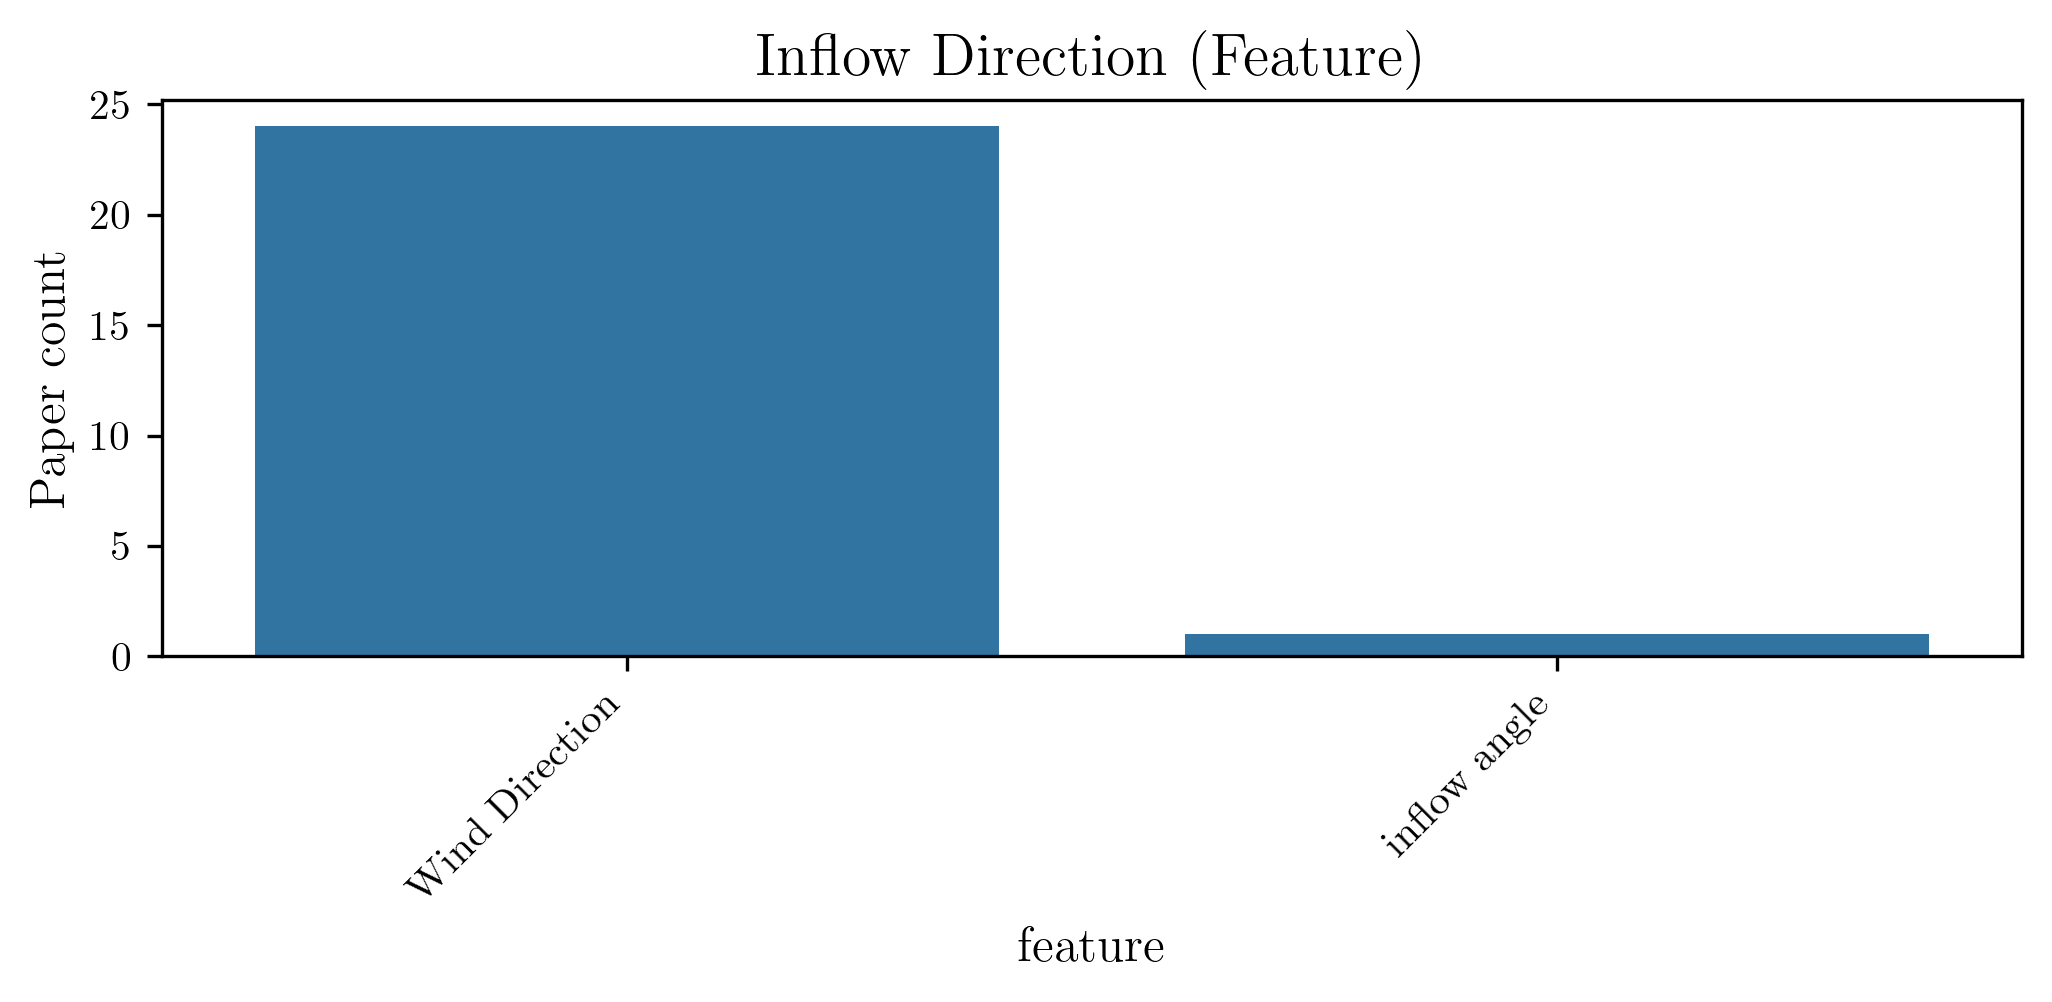

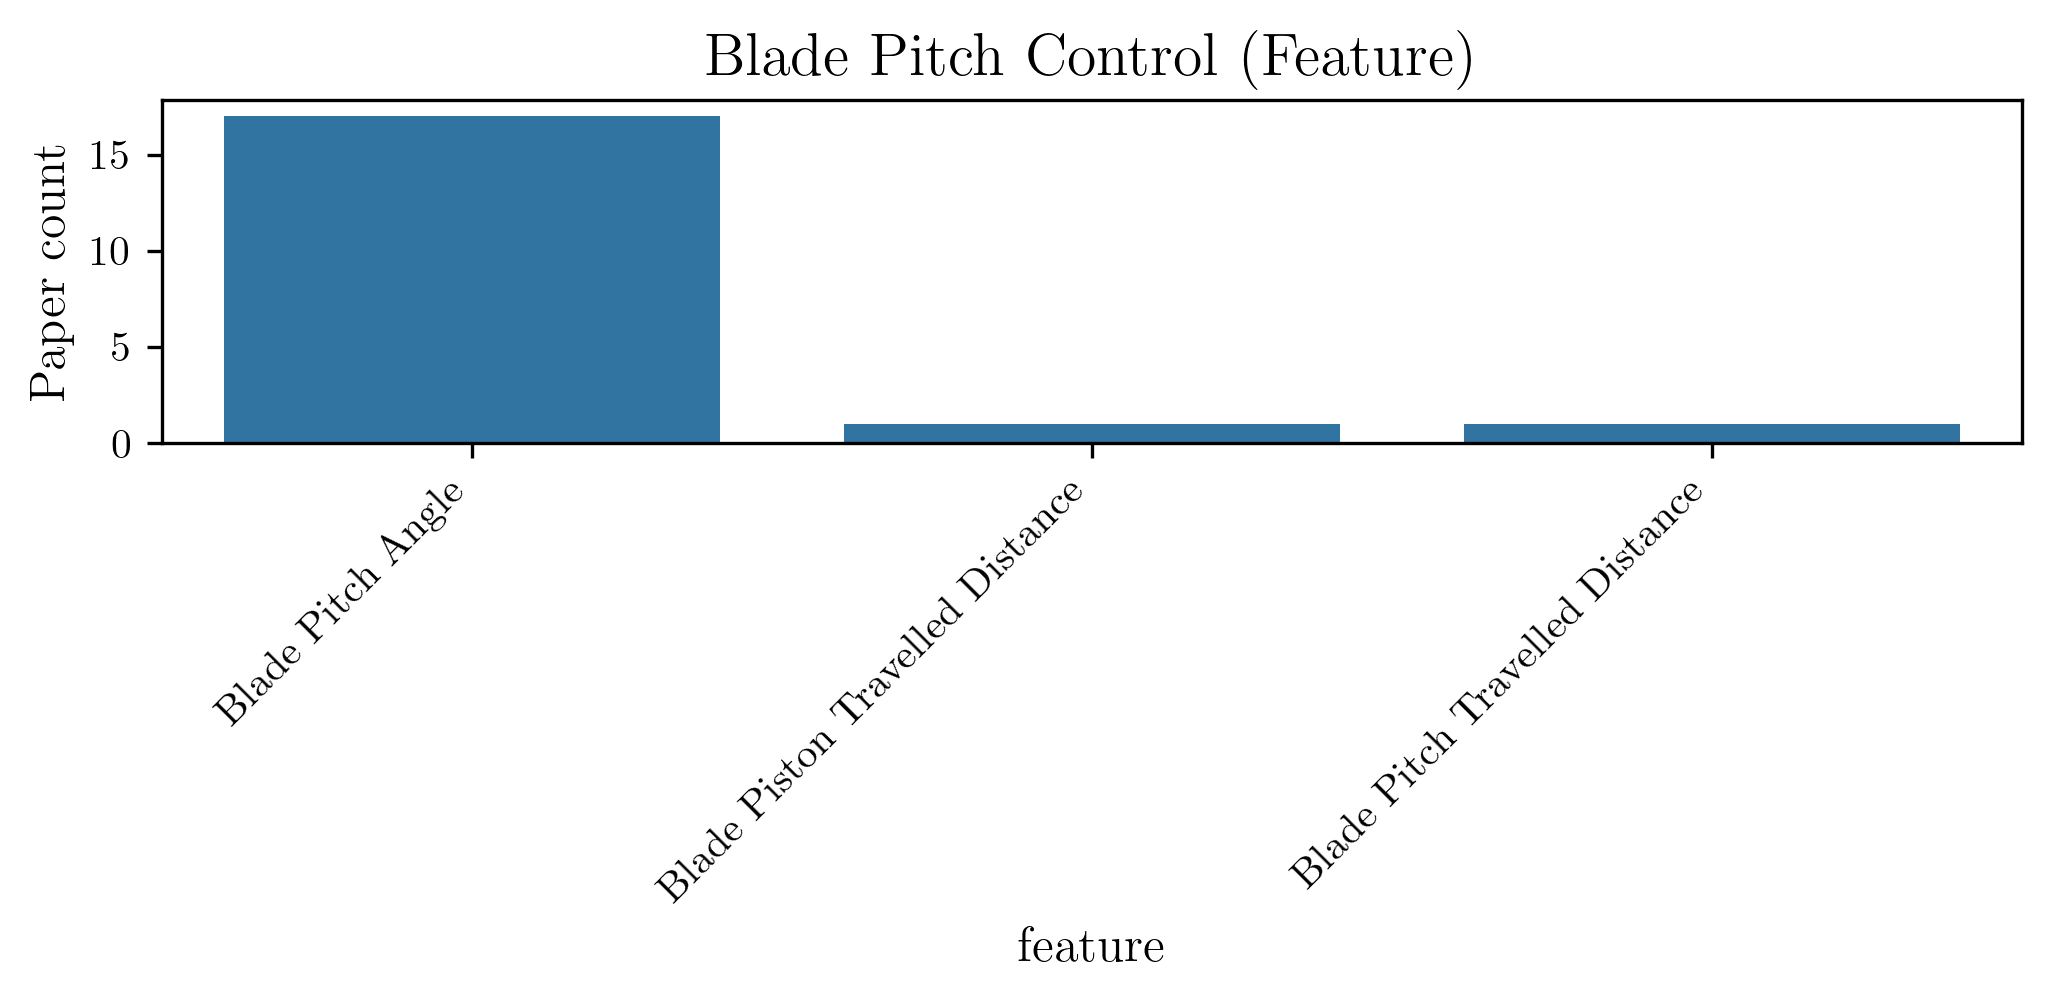

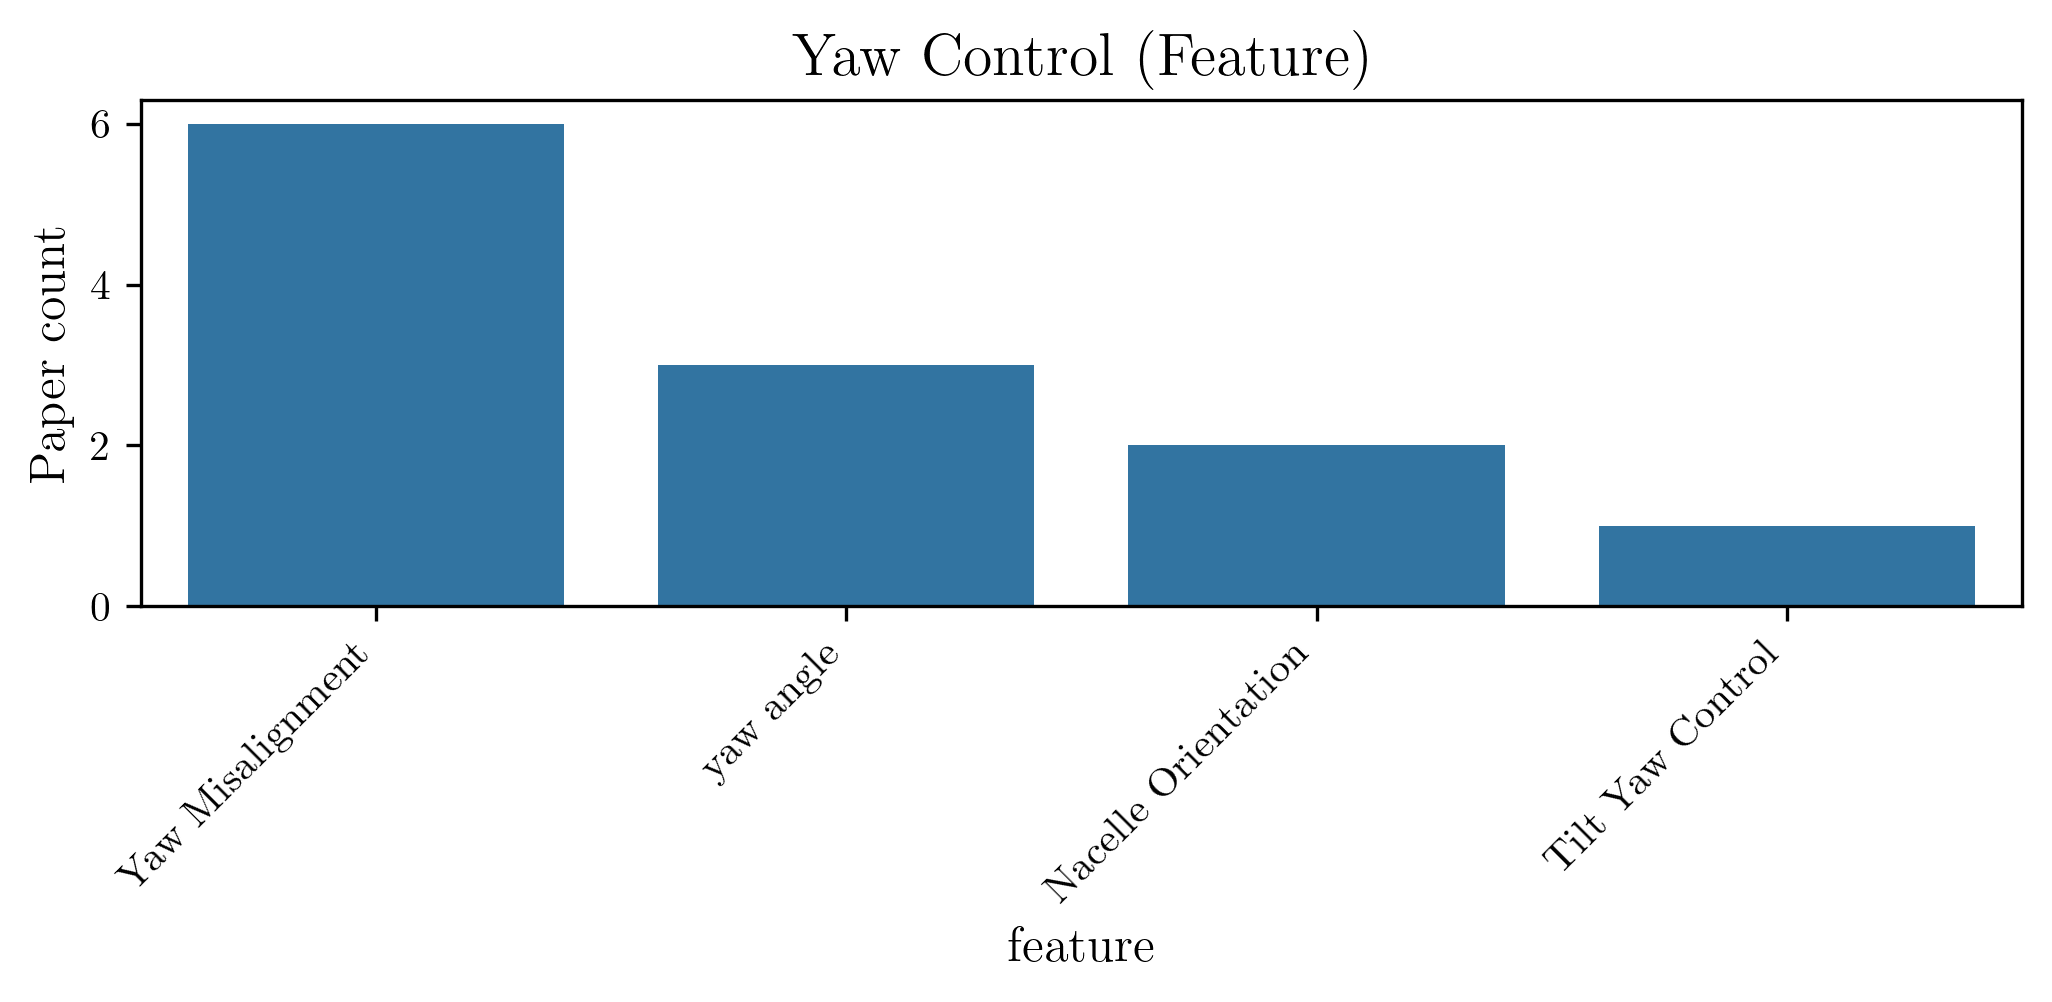

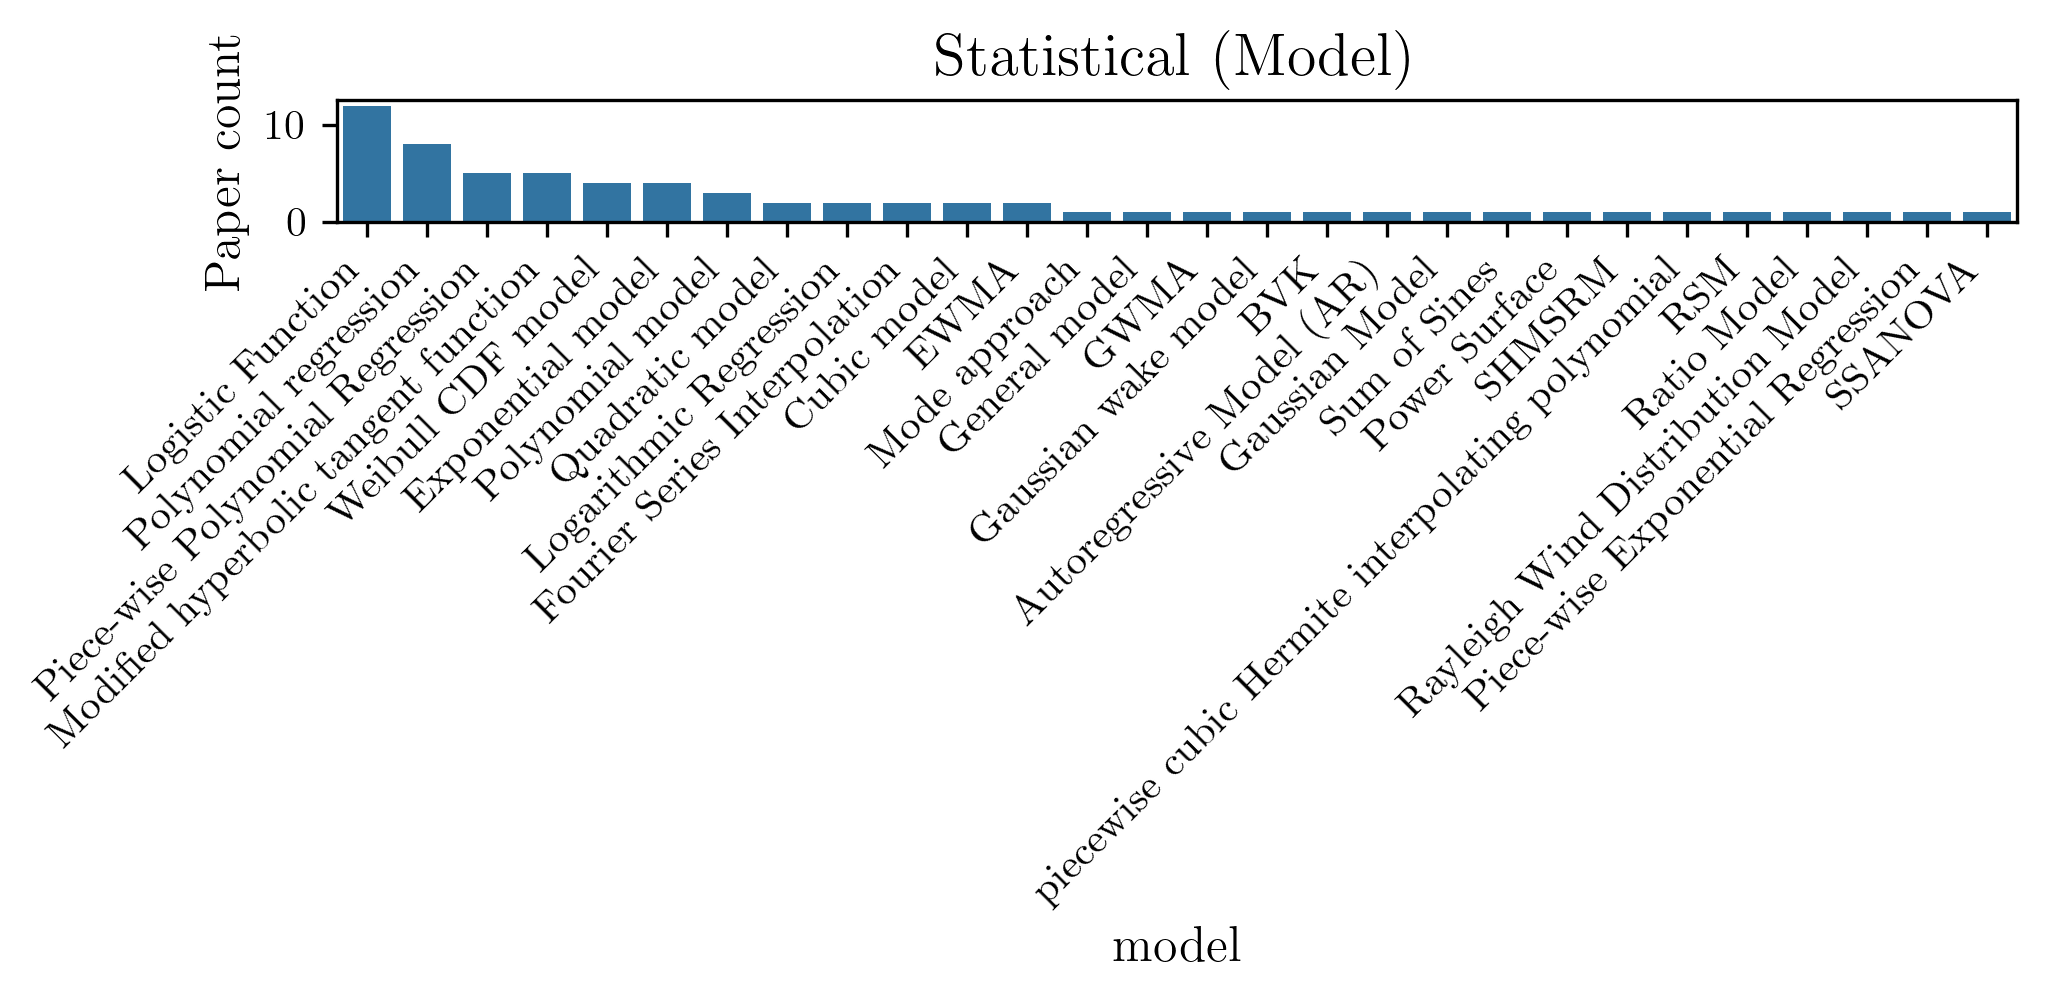

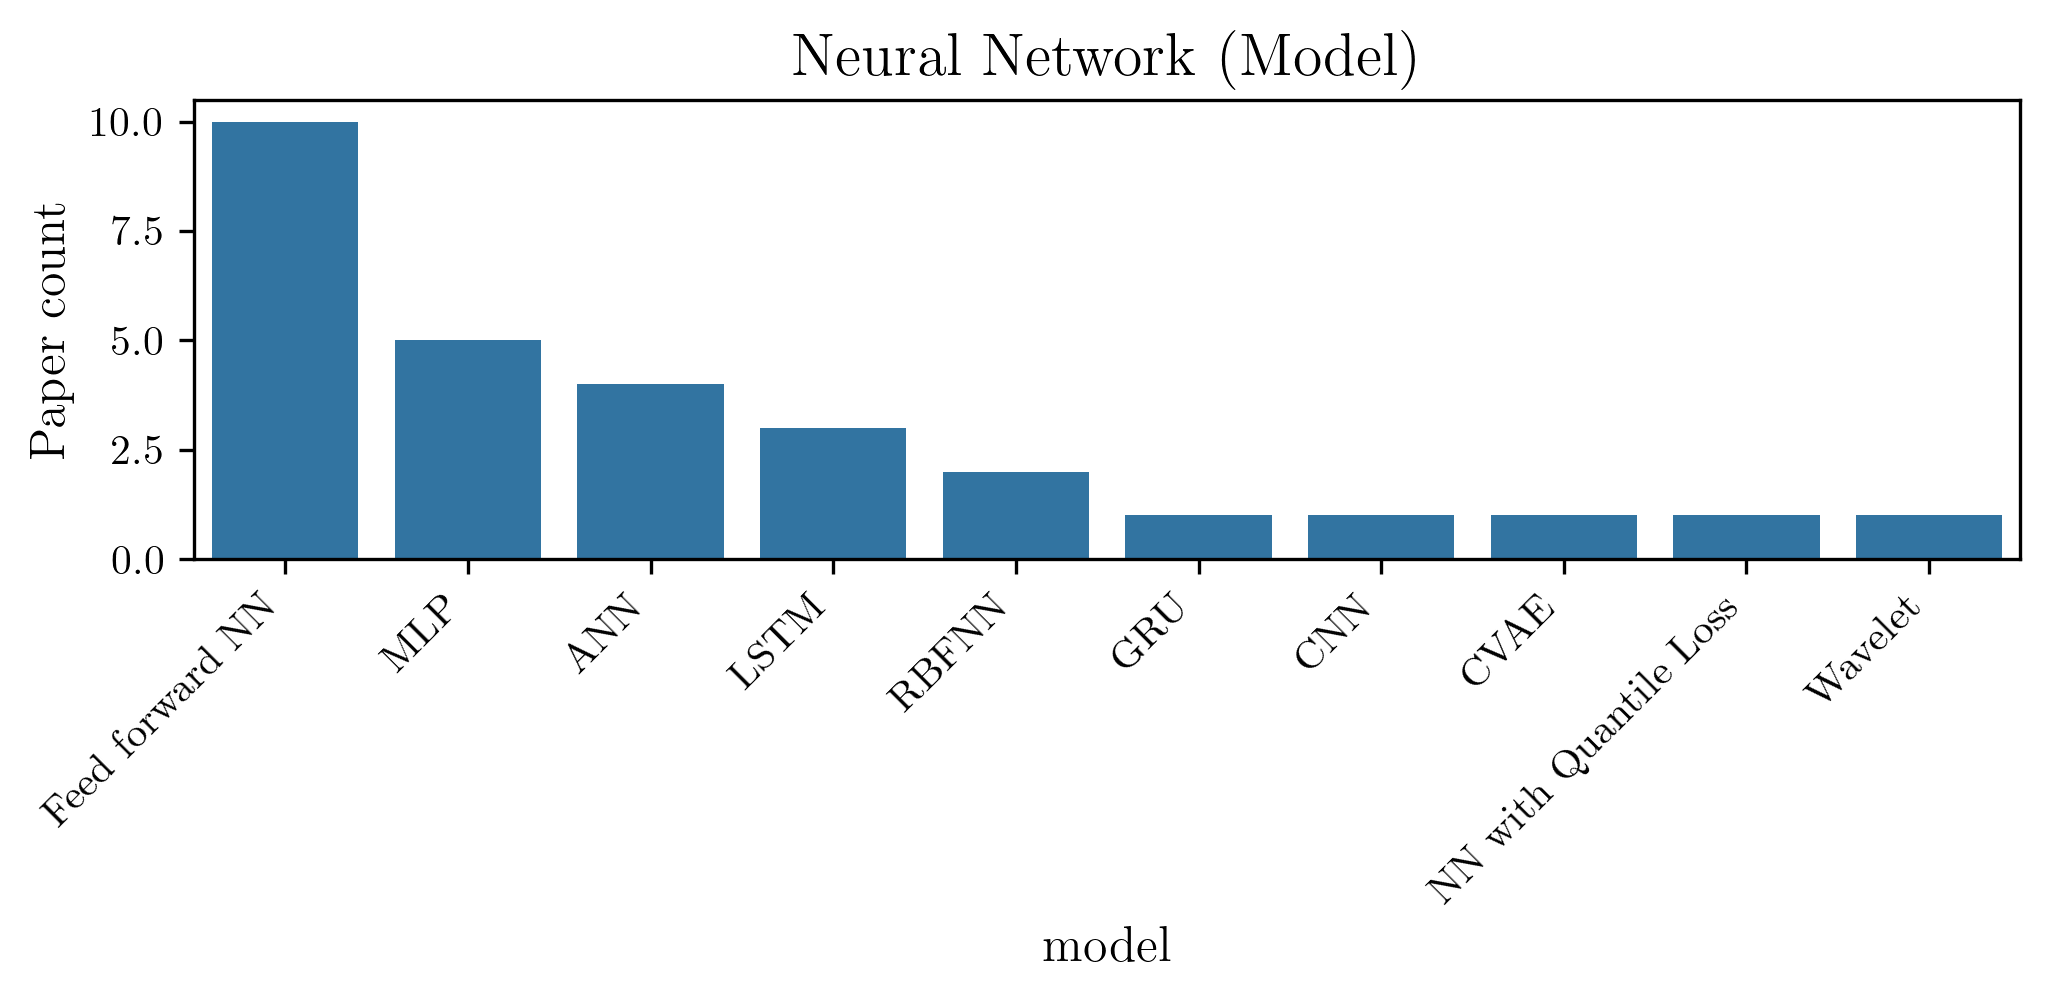

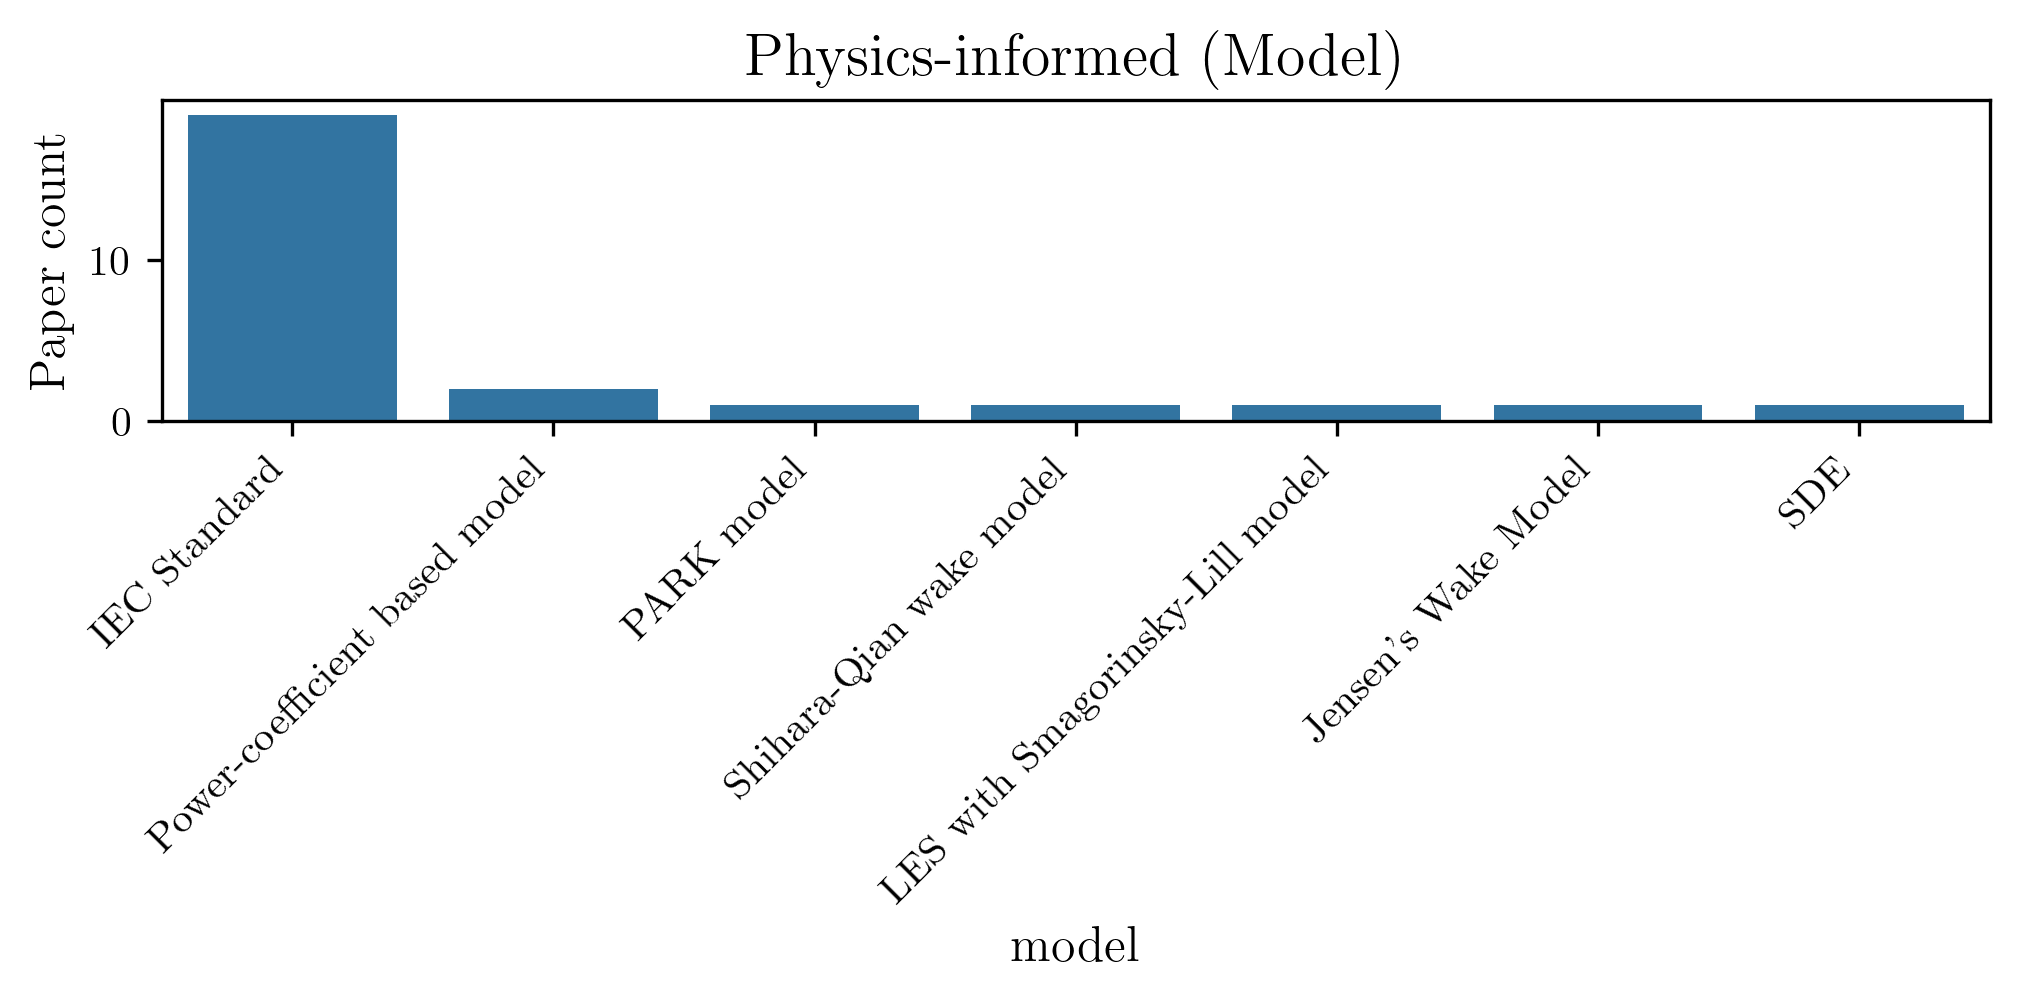

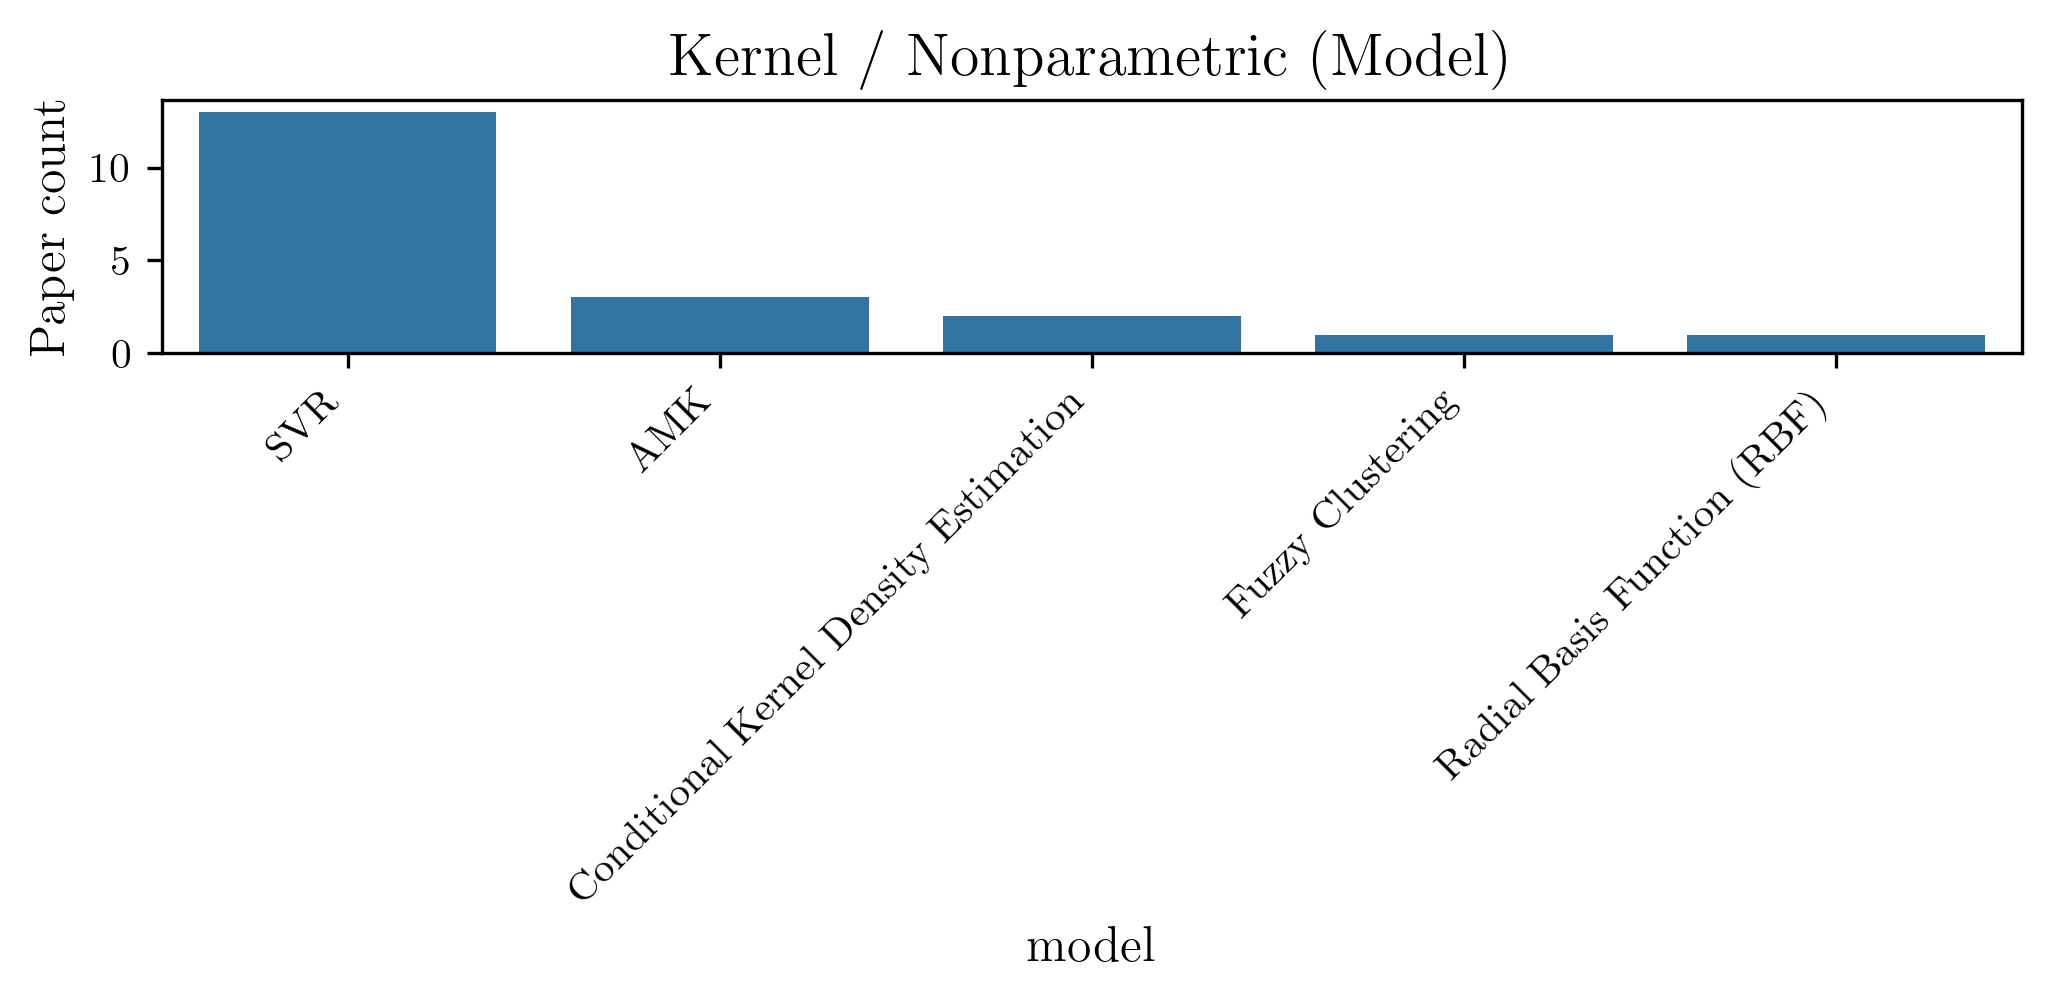

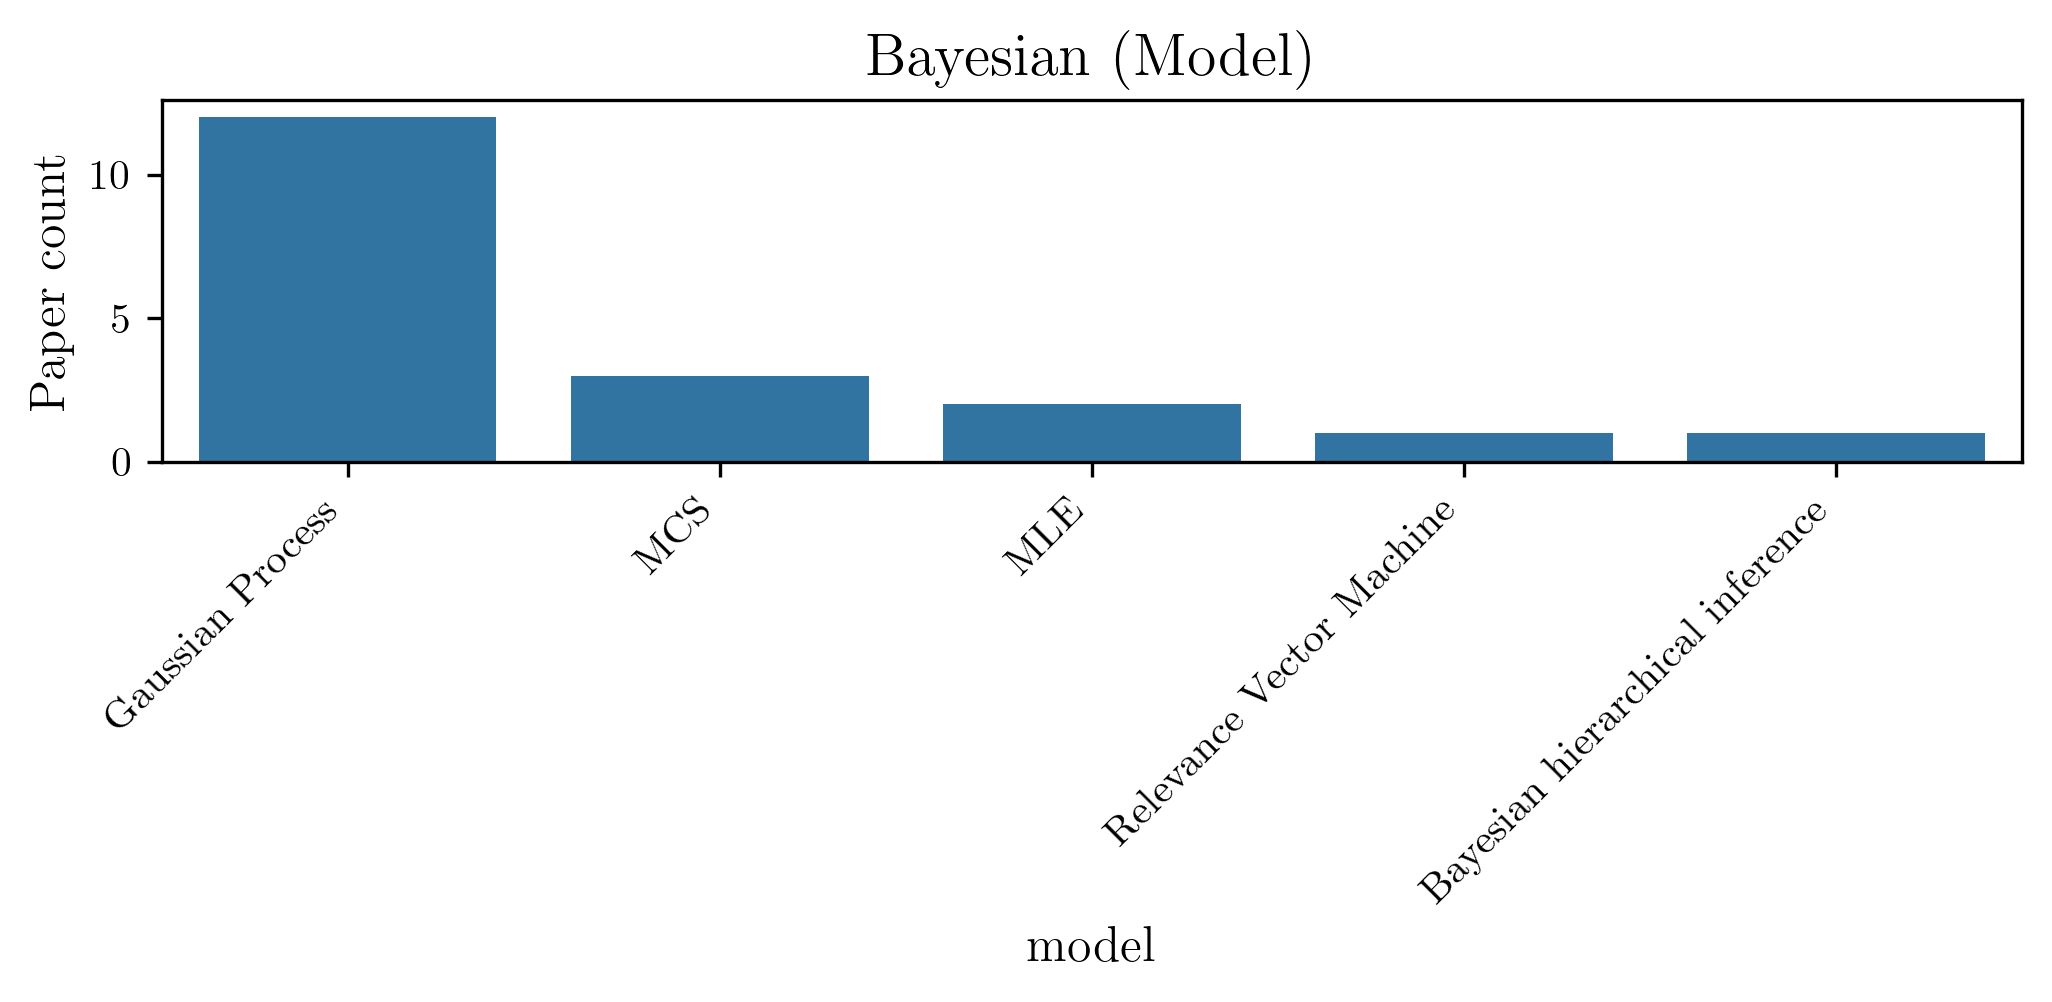

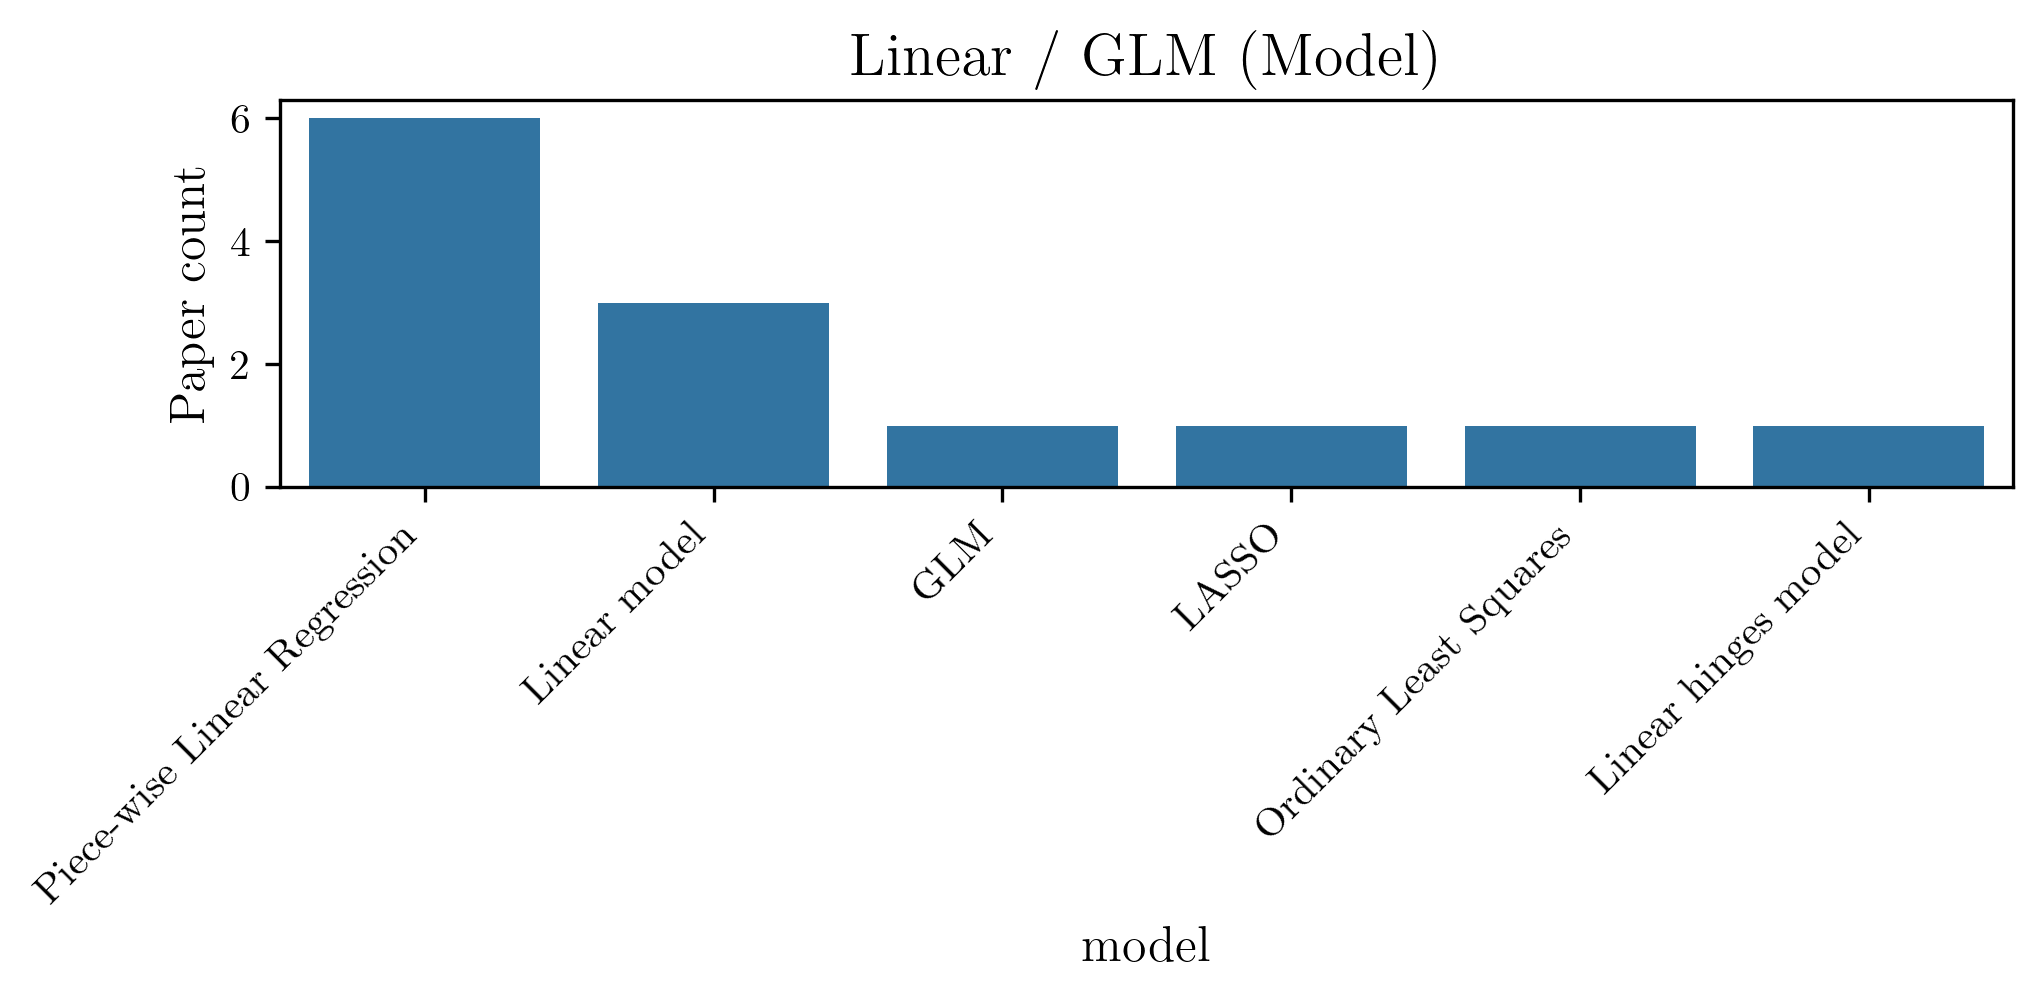

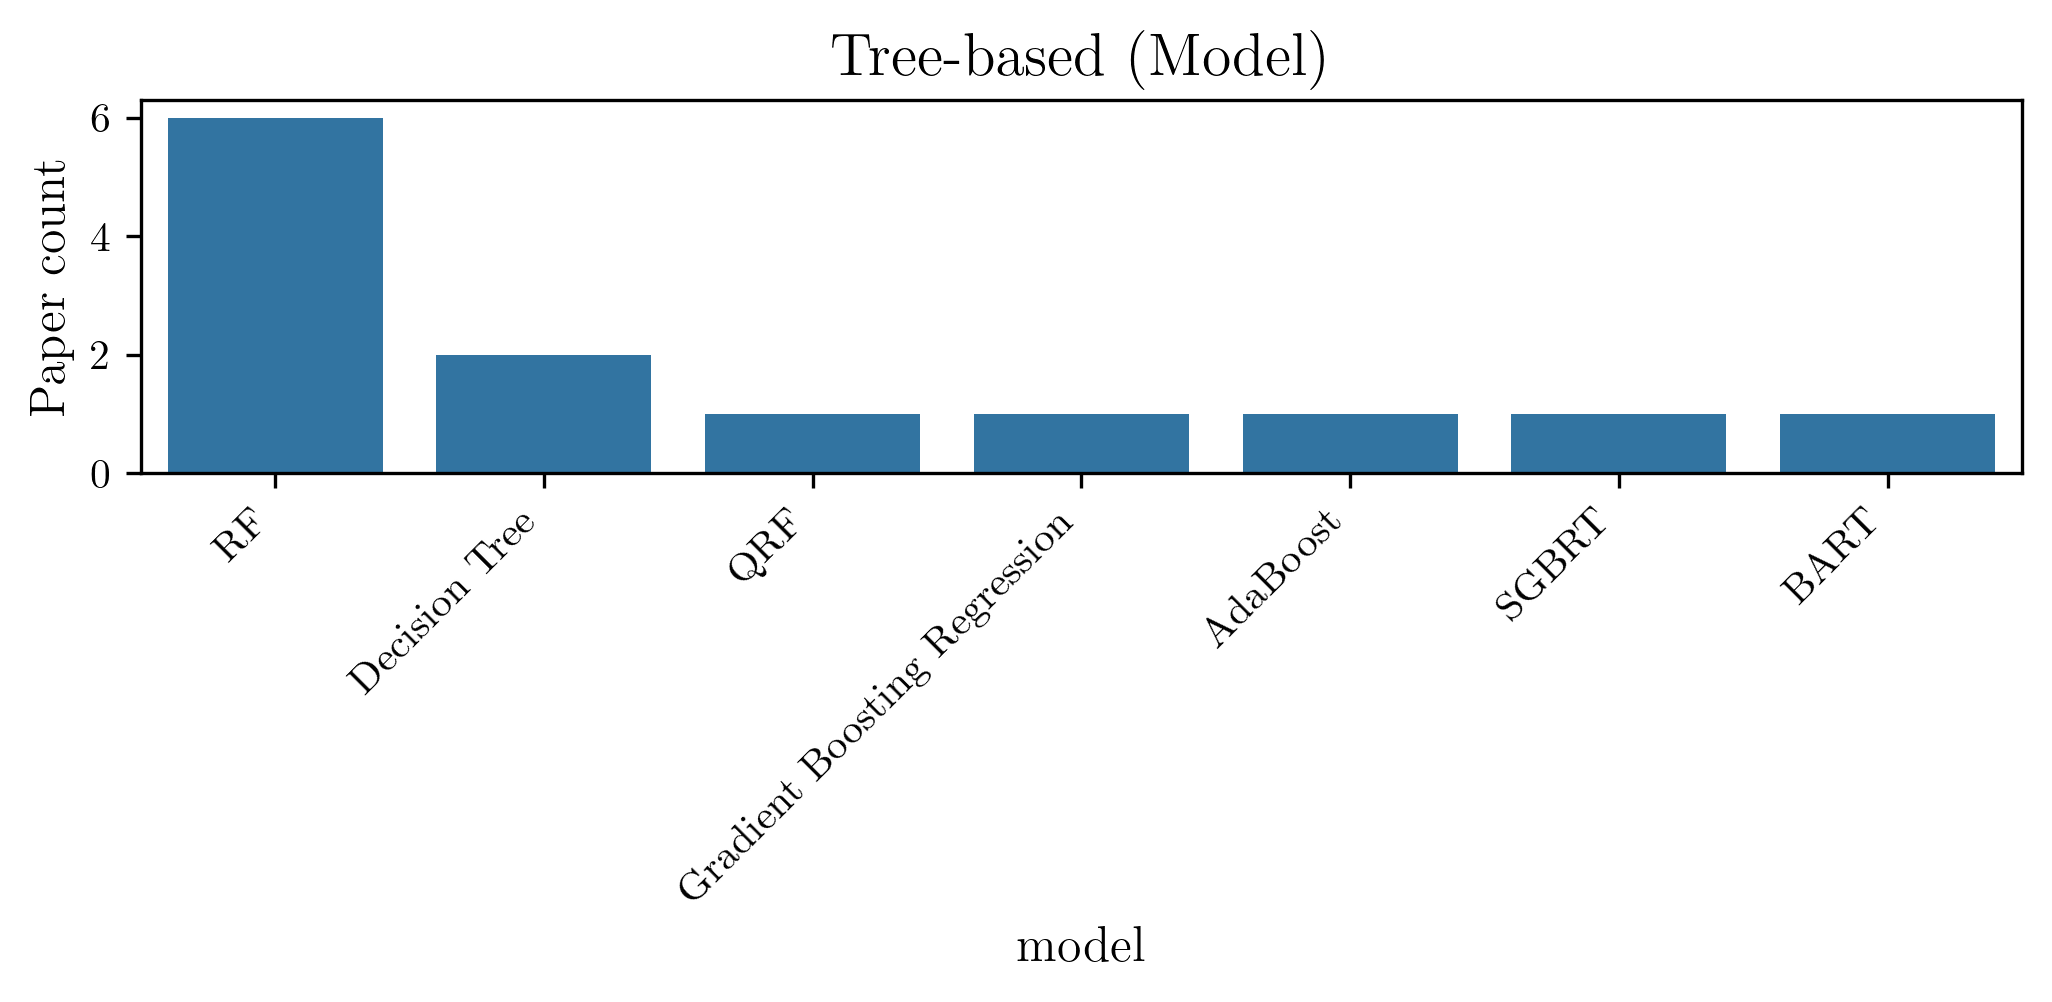

In [12]:
# Additional barplots for selected supercategories

# Supercategories you want to analyze in detail
target_supercategories = {
    "feature": ["Inflow Direction", "Blade Pitch Control", "Yaw Control"],
    "model": ["Statistical", "Neural Network", "Physics-informed", "Kernel / Nonparametric", "Bayesian", "Linear / GLM",
              "Tree-based"]
}

# For each type (feature/model), extract and plot sub-categories
for coltype, categories in target_supercategories.items():
    colname_raw = "Used Features" if coltype == "feature" else "Used Models"

    df_expanded = df_wind.loc[:, ["doi", colname_raw]].rename(columns={colname_raw: coltype})
    df_expanded = df_expanded.explode(coltype).drop_duplicates()

    for category in categories:
        # Get all items that map to the given supercategory
        reverse_map = {k: v for k, v in rename_dict[coltype].items() if v == category}
        items_in_category = list(reverse_map.keys())

        # Filter and count
        subset = df_expanded[df_expanded[coltype].isin(items_in_category)]
        counts = subset[coltype].value_counts().reset_index()
        counts.columns = [coltype, "count"]

        # Plot
        sns.barplot(data=counts, x=coltype, y="count")
        plt.title(f"{category} ({coltype.capitalize()})")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Paper count")
        plt.tight_layout()
        plt.show()


In [13]:
usage_counts["feature"].value_counts()

feature
1          38
2          14
5          10
3           9
4           6
6           4
7           4
8           2
9           1
12          1
15          1
Name: count, dtype: int64

# 2. Final Paper Figure With Most Frequent Variables in Both Domains

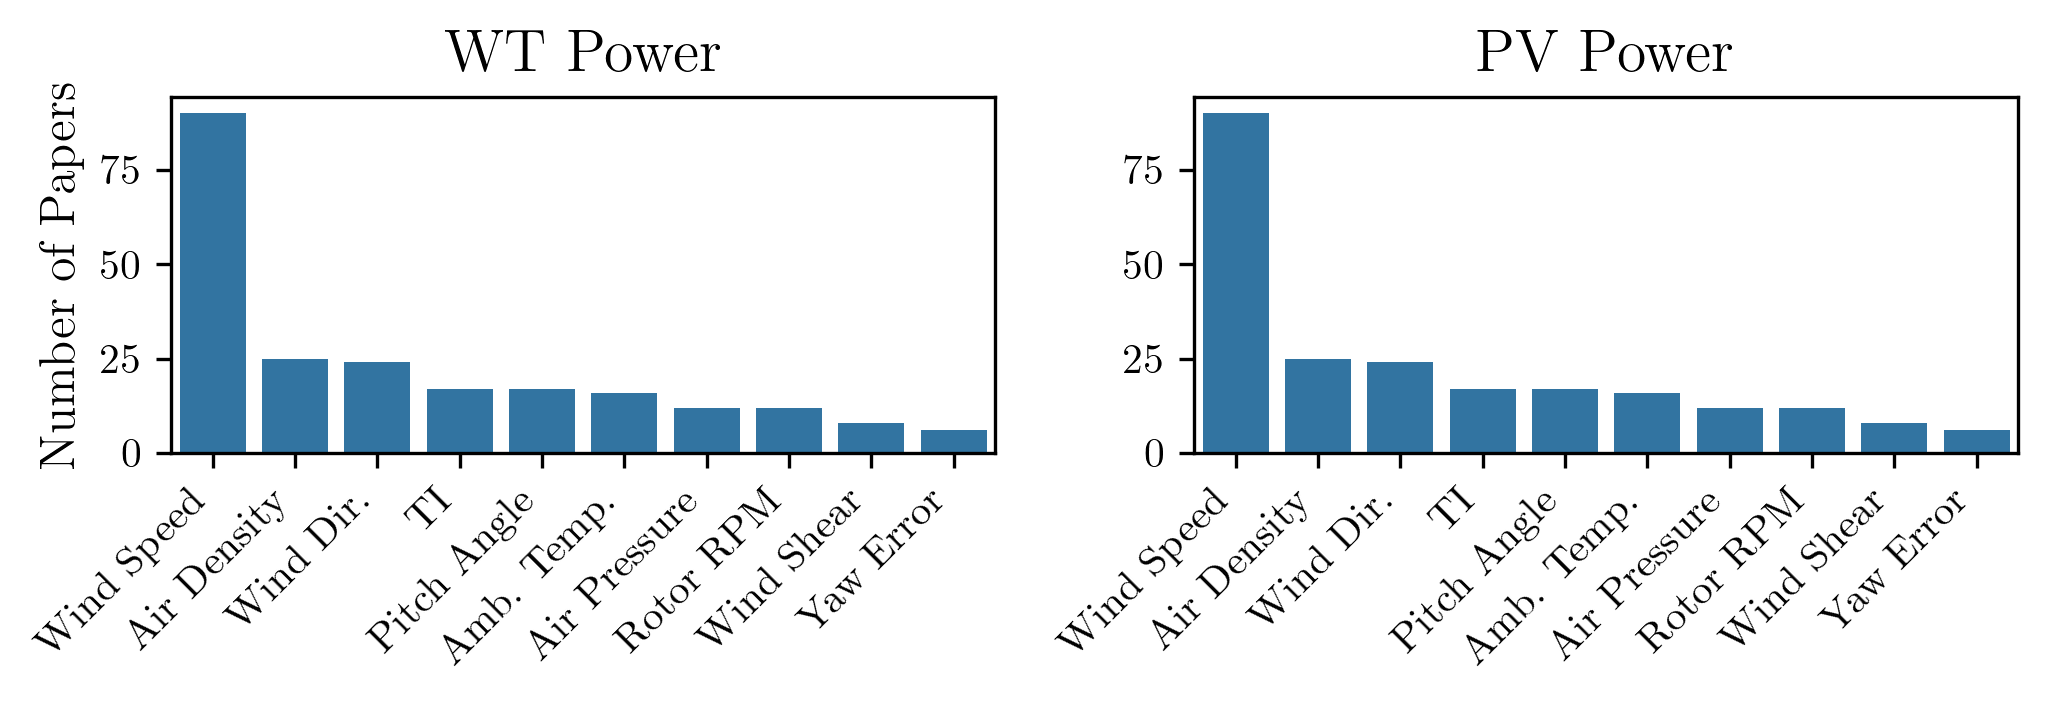

In [14]:
short_names = {
    "feature": {
        "Wind Direction": "Wind Dir.",
        "Turbulence Intensity": "TI",
        "Ambient Temperature": "Amb. Temp.",
        "Yaw Misalignment": "Yaw Error",
        "Blade Pitch Angle": "Pitch Angle",

        # "PV Power": "Lagged PV Power",
        "Sunshine Hours": "Sunshine Hrs",

    },
}

fig_title = "feature_count"
# Global bar plots: top 10 individual items (raw names, not grouped into supercategories)
usage_counts = {}
counts = {}
fig, axs = plt.subplots(ncols=2, figsize=(7, 2.5))
i = 0
for domain, curr_df in zip(["WT Power", "PV Power"], [df_wind, df_wind]):
    ax = axs[i]

    coltype = "feature"

    # Prepare data
    curr_df = curr_df.copy()
    if "doi" not in curr_df.columns:
        curr_df["paper_id"] = np.arange(len(curr_df))
    else:
        curr_df["paper_id"] = curr_df["doi"]
    df_expanded = curr_df.loc[:, ["paper_id", "Used Features"]].rename(columns={"Used Features": "feature"})
    df_expanded = df_expanded.explode(coltype)

    df_expanded[coltype] = df_expanded[coltype].replace(
        short_names[coltype]
    )

    df_expanded = df_expanded.loc[df_expanded[coltype] != "PV Power"] # Only consider indirect PV predictions without historical PV power feature

    df_expanded = df_expanded.drop_duplicates()
    usage_counts[coltype] = df_expanded.groupby("paper_id").count()  #.value_counts()



    # Count and take top 10
    counts[coltype] = df_expanded[coltype].value_counts().head(10).reset_index()
    counts[coltype].columns = [coltype, "count"]

    # Plot
    sns.barplot(data=counts[coltype], x=coltype, y="count", ax=ax)
    # fig_title = f"Top 10 {coltype.capitalize()}s (Raw Frequency)"
    # ax.set_title(fig_title)
    ax.set_xlabel("")  # xlabel)
    if i==0:
        ax.set_ylabel("Number of Papers")
    else:
        ax.set_ylabel("")
    ax.set_title(domain)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    i+=1
plt.tight_layout()
plt.show()